**instructions:**
1) Use TAB corresponding to the instrument to
    - load transit corresponding to data to process
    - load corresponding s1d files or create s1d spectra if required
    - check if s1d files are in earth/barycentric rf and vac/air defined
    - build CSV file with list of files to process

2) Update Molecfit_run_parallelized with instrument tag & path to CSV

3) Launch: python Molecfit_run_parallelized.py. Status code 1/2/3 means convergence.

4) Use the plot tab to show the result from the last output folder

In [16]:
import os
import numpy as np
import sys
from astropy.io import fits
import astropy.constants as const
sys.path.append('/home/amasson/data/Kaperture_Science/HR-SpARTA_priv/core modules/')

from transits_info import *
from reduction import *


In [17]:
# use Jupyter magic's fonction autoreload : reload modules each time the code is executed
%load_ext autoreload
%autoreload 2
%matplotlib widget
# enable the Jupyter plugin to monitor execution times
# !jupyter nbextension enable execute_time/ExecuteTime


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Build HARPS

In [13]:
# first we load a dataset from the transit to correct
transit = TOI969_03_2024_HARPS

dd = DataSet()
dd.load_HARPS_data(transit)


Loading files in '/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/HARPS/03-03-2024/' :
61 out of 670 files selected !

Building data cube of shape : (61, 72, 4096)
Filling the data cube with selected files...
Function to build HARPS wavelength solution has directly been extracted from the open-source sBART tool (https://github.com/iastro-pt/sBART/): please contact and cite relevant authors!
Note that we arbitrary take the SNR from header corresponding to order 30, as SNR has the same relative behavior along time in all orders
No molecfit telluric correction files found in /home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/HARPS/03-03-2024/: CAN'T APPLY TELLURIC CORRECTION !!! RUN MOLECFIT FIRST ON S1D FILES TO GENERATE THE TELLURIC TEMPLATE, THEN STORE THE FILES IN WITH "Telluric_Correction_Molecfit" IN NAME IN SAME FOLDER AS DATA !!

Building the off-transit spectra masked :

61 / 61
Found 45 off-transit spectra among 61 spectra

Find off transit spect

In [14]:
# just some preprocessing so that data are normalized. E2ds are already in Earth RF for HARPS
dd.norm_with_scaler()
dd.norm_with_median()



Normalization with scaler along observations done !
Negative values detected: adding a constant term to ensure all data are strictly positive. Resulting data may not be centered at 1 but will be relatively normalized: just perform a normalization by master spec to bring back to 1.

This step has been saved with ID : 'norm_with_scaler'
------------------------------

Normalization with median along observations done !

This step has been saved with ID : 'norm_with_median'
------------------------------


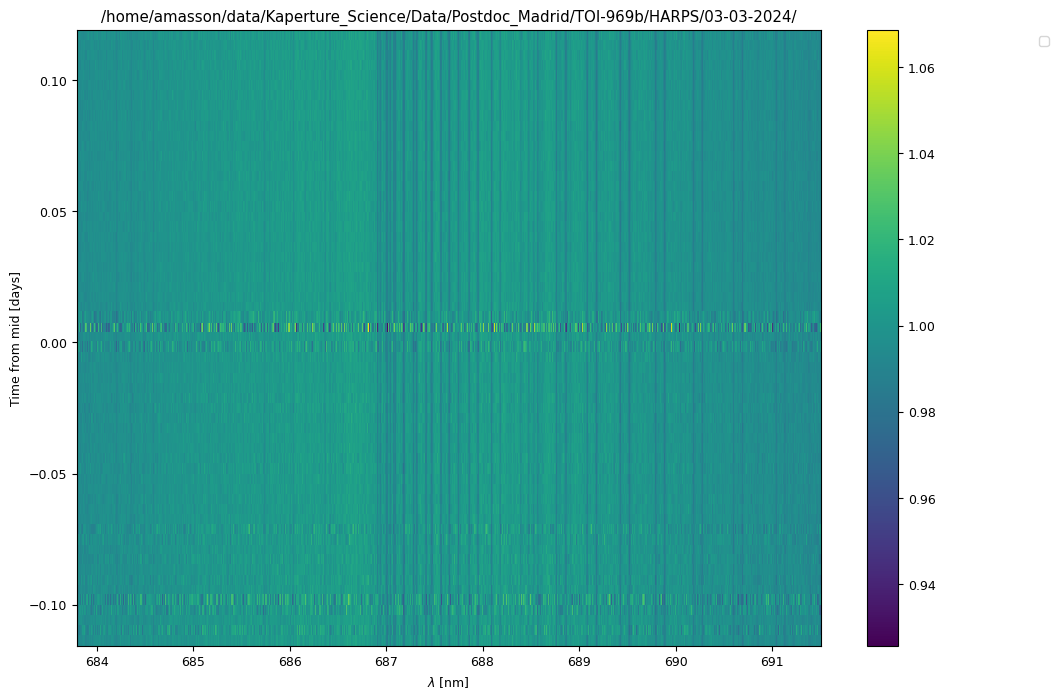

In [15]:
dd.plot_imshow(-1)


In [16]:
# now generate a csv files with path to each s1d fits to correct + the redshift of the stellar lines in Earth RF (for excluding stellar lines)
fits_list = [dd.path + f.replace('e2ds','s1d') for f in dd.files] # list of s1d files corresponding to the e2ds files in the dataset

# generate csv file
with open(f'./Automated_Program/{dd.name}.csv','w') as f:
    f.write('file\n')
    for file,berv in zip(fits_list[:1],dd.BERV[:1]):
        f.write(f'{file},{berv}\n')
print(f'./Automated_Program/{dd.name}.csv')


./Automated_Program/TOI-969b_HARPS_03-03-2024.csv


In [17]:
fits_list


['/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/HARPS/03-03-2024/HARPS.2024-03-03T23:59:42.310_s1d_A.fits',
 '/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/HARPS/03-03-2024/HARPS.2024-03-04T00:05:14.918_s1d_A.fits',
 '/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/HARPS/03-03-2024/HARPS.2024-03-04T00:10:47.916_s1d_A.fits',
 '/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/HARPS/03-03-2024/HARPS.2024-03-04T00:16:20.916_s1d_A.fits',
 '/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/HARPS/03-03-2024/HARPS.2024-03-04T00:21:52.914_s1d_A.fits',
 '/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/HARPS/03-03-2024/HARPS.2024-03-04T00:27:25.903_s1d_A.fits',
 '/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/HARPS/03-03-2024/HARPS.2024-03-04T00:32:57.931_s1d_A.fits',
 '/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/HARPS/03-03-2024/HARPS.2024-03-04T00

In [18]:
# open a s1d file to check if in same RF as the e2ds
s1d = fits.open(fits_list[0])


In [19]:
s1d.info()


Filename: /home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/HARPS/03-03-2024/HARPS.2024-03-03T23:59:42.310_s1d_A.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    3350   (312947,)   float32   


In [20]:
# for HARPS we need to manually build the wavelength solution. Here using same method as in the molecfit wrapper
from Molecfit_run_parallelized import _wavelength_from_harps_drs_header
wave_s1d = _wavelength_from_harps_drs_header(s1d[0].header)


In [21]:
s1d[0].header


SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                  -32 / number of bits per data pixel                  
NAXIS   =                    1 / number of data axes                            
NAXIS1  =               312947 / length of data axis 1                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
CRPIX1  =                   1. / Reference pixel                                
CRVAL1  =              3783.18 / Coordinate at reference pixel                  
CDELT1  =                 0.01 / Coordinate increment par pixel                 
CTYPE1  = 'Angstrom'           / Units of coordinate                            
BUNIT   = 'Relative Flux'      / Units of data values                           
ORIGIN  = 'TEST    '        

In [22]:
crval = s1d[0].header["CRVAL1"]
cdelt = s1d[0].header["CDELT1"]
npix  = s1d[0].header["NAXIS1"]

wave_s1d = crval + np.arange(npix) * cdelt


In [23]:
# e2ds are in Earth, and s1d in barycentric: put e2ds in barycentric to verify that s1d are indeed in barycentric
dd.doppler_shift(prebuilt='earth_to_berv')


Shifting with 10 oversampling factor:
4392/4392

Doppler shifting done !

This step has been saved with ID : 'doppler_shift'
------------------------------


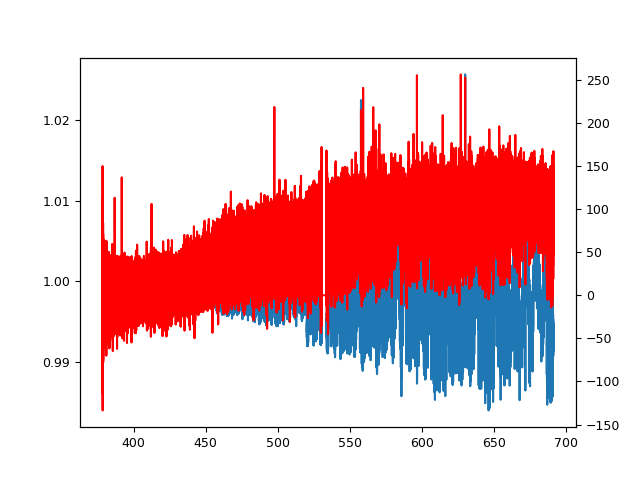

In [24]:
# check e2ds Vs s1d
%matplotlib widget
plt.figure()
plt.plot(dd.wave[0].flatten(),dd.weighted_mean(dd.data).flatten())
plt.twinx().plot(wave_s1d*1.000276/10,s1d[0].data,color='r')

# ok so for HARPS, our s1d wavelength solution is by default in AIR and in BARYCENTRIC RF -> we updated Molecfit Wrapper to automatically consider HARPS s1d in barycentric - air


### Build NIRPS -> no need for Molecfit, telluric template already exist!

Loading files in '/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/NIRPS/03-03-2024/' :
38 out of 199 files selected !

Building data cube of shape : (38, 71, 4084)
Filling the data cube with selected files...
Note that we arbitrary take the SNR from header corresponding to order 30, as SNR has the same relative behavior along time in all orders
Found 38 molecfit telluric correction files in /home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/NIRPS/03-03-2024/
Tellurics have been saved as attribute. Run data_set.apply_telluric_correction() to apply correction !

Building the off-transit spectra masked :

38 / 38
Found 26 off-transit spectra among 38 spectra

Find off transit spectra done !

This step has been saved with ID : 'find_off_transit'
------------------------------
Compute Kepler orbit done
Compute transit window weight orbit done
Removed empty or null columns from data cube

38 files have been succesfully loaded from '/home/amasson/data/Kapertur

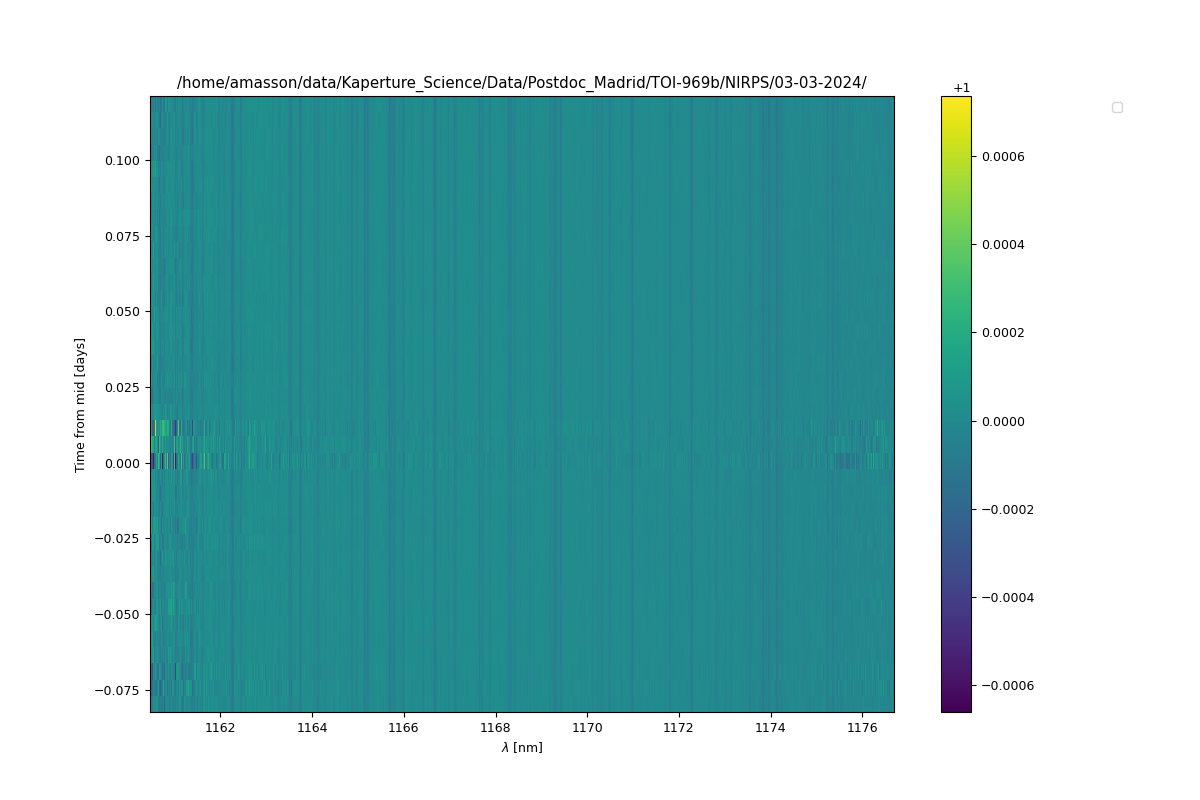

In [113]:
# first we load a dataset from the transit to correct
transit = TOI969_03_2024_NIRPS

dd = DataSet()
dd.load_NIRPS_data(transit)

dd.norm_with_scaler()
dd.norm_with_median()
dd.plot_imshow(24)


In [39]:
# now generate a csv files with path to each s1d fits to correct + the redshift of the stellar lines in Earth RF (for excluding stellar lines)
fits_list = [dd.path + f.replace('S2D_SKYSUB','S1D_FINAL').replace(':','-') for f in dd.files] # list of s1d files corresponding to the e2ds files in the dataset

# generate csv file
with open(f'./Automated_Program/{dd.name}.csv','w') as f:
    f.write('file\n')
    for file,berv in zip(fits_list[:1],dd.BERV[:-1]):
        f.write(f'{file},{berv}\n')
print(f'./Automated_Program/{dd.name}.csv')


./Automated_Program/TOI-969b_NIRPS_03-03-2024.csv


In [40]:
fits_list


['/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/NIRPS/03-03-2024/r.NIRPS.2024-03-04T00-46-10.407_S1D_FINAL_A.fits',
 '/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/NIRPS/03-03-2024/r.NIRPS.2024-03-04T00-53-52.985_S1D_FINAL_A.fits',
 '/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/NIRPS/03-03-2024/r.NIRPS.2024-03-04T01-01-35.563_S1D_FINAL_A.fits',
 '/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/NIRPS/03-03-2024/r.NIRPS.2024-03-04T01-09-18.141_S1D_FINAL_A.fits',
 '/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/NIRPS/03-03-2024/r.NIRPS.2024-03-04T01-17-00.720_S1D_FINAL_A.fits',
 '/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/NIRPS/03-03-2024/r.NIRPS.2024-03-04T01-24-43.297_S1D_FINAL_A.fits',
 '/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/NIRPS/03-03-2024/r.NIRPS.2024-03-04T01-32-25.875_S1D_FINAL_A.fits',
 '/home/amasson/data/Kaperture_Science/Data/Post

In [41]:
s1d = fits.open(fits_list[0])
s1d.info()


Filename: /home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/NIRPS/03-03-2024/r.NIRPS.2024-03-04T00-46-10.407_S1D_FINAL_A.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    1322   ()      
  1  SPECTRUM      1 BinTableHDU    181   1R x 31C   [221629D, 221629D, 221629D, 221629J, 221629D, 221629D, 221629D, 221629D, 221629J, 221629D, 221629D, 221629J, 221629D, 221629D, 221629J, 221629D, 221629D, 221629J, 221629D, 221629D, 221629J, 221629D, 221629D, 221629D, 221629J, 221629D, 221629D, 221629J, 221629D, 221629D, 221629J]   


In [42]:
s1d[1].header


XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / 8-bit bytes                                    
NAXIS   =                    2 / 2-dimensional binary table                     
NAXIS1  =             46985348 / width of table in bytes                        
NAXIS2  =                    1 / number of rows in table                        
PCOUNT  =                    0 / size of special data area                      
GCOUNT  =                    1 / one data group (required keyword)              
TFIELDS =                   31 / number of fields in each row                   
TTYPE1  = 'WAVE    '           / label for field   1                            
TFORM1  = '221629D '           / data format of field: 8-byte DOUBLE            
TUNIT1  = 'angstrom'           / physical unit of field                         
TTYPE2  = 'FLUX    '           / label for field   2                            
TFORM2  = '221629D '        

In [43]:
s1d_flux = s1d[1].data['Flux'][0]
s1d_wave = s1d[1].data['Wave'][0]
print(s1d_flux.shape,s1d_wave.shape)


(221629,) (221629,)


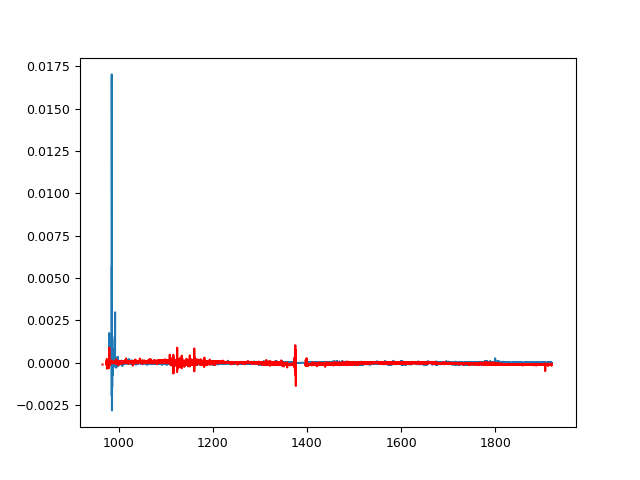

In [55]:
# plot e2ds VS s1d. e2ds from NIRPS are in VAC and BARYCENTRIC by default
%matplotlib widget
plt.figure()
plt.plot(dd.wave[0].flatten(),dd.weighted_mean(dd.data).flatten()-1) # norm & center at 0, adjust scale for better comparison
plt.plot(s1d_wave/10, (s1d_flux/np.nanmedian(s1d_flux)  - 1)* 1e-4,color='r') # norm & center at 0, adjust scale for better comparison

# ok so NIRPS s1d files seems to already have their tellurics masked
# and S1D NIRPS are in BARYCENTRIC and VACUUM


In [56]:
dd.files


['r.NIRPS.2024-03-04T00:46:10.407_S2D_SKYSUB_A.fits',
 'r.NIRPS.2024-03-04T00:53:52.985_S2D_SKYSUB_A.fits',
 'r.NIRPS.2024-03-04T01:01:35.563_S2D_SKYSUB_A.fits',
 'r.NIRPS.2024-03-04T01:09:18.141_S2D_SKYSUB_A.fits',
 'r.NIRPS.2024-03-04T01:17:00.720_S2D_SKYSUB_A.fits',
 'r.NIRPS.2024-03-04T01:24:43.297_S2D_SKYSUB_A.fits',
 'r.NIRPS.2024-03-04T01:32:25.875_S2D_SKYSUB_A.fits',
 'r.NIRPS.2024-03-04T01:40:08.454_S2D_SKYSUB_A.fits',
 'r.NIRPS.2024-03-04T01:47:51.032_S2D_SKYSUB_A.fits',
 'r.NIRPS.2024-03-04T01:55:33.610_S2D_SKYSUB_A.fits',
 'r.NIRPS.2024-03-04T02:03:16.188_S2D_SKYSUB_A.fits',
 'r.NIRPS.2024-03-04T02:10:58.766_S2D_SKYSUB_A.fits',
 'r.NIRPS.2024-03-04T02:18:41.344_S2D_SKYSUB_A.fits',
 'r.NIRPS.2024-03-04T02:26:23.922_S2D_SKYSUB_A.fits',
 'r.NIRPS.2024-03-04T02:34:06.500_S2D_SKYSUB_A.fits',
 'r.NIRPS.2024-03-04T02:41:49.079_S2D_SKYSUB_A.fits',
 'r.NIRPS.2024-03-04T02:49:31.657_S2D_SKYSUB_A.fits',
 'r.NIRPS.2024-03-04T02:57:14.235_S2D_SKYSUB_A.fits',
 'r.NIRPS.2024-03-04T03:04:5

In [59]:
# check the data we have at hand for NIRPS
blaze_a = fits.open('/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/NIRPS/03-03-2024/r.NIRPS.2024-03-04T00:46:10.407_S2D_BLAZE_A.fits')
blaze_a.info()


Filename: /home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/NIRPS/03-03-2024/r.NIRPS.2024-03-04T00:46:10.407_S2D_BLAZE_A.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    1113   ()      
  1  SCIDATA       1 ImageHDU        10   (4084, 71)   float32   
  2  ERRDATA       1 ImageHDU        10   (4084, 71)   float32   
  3  QUALDATA      1 ImageHDU        12   (4084, 71)   int16 (rescales to uint16)   
  4  WAVEDATA_VAC_BARY    1 ImageHDU        10   (4084, 71)   float64   
  5  WAVEDATA_AIR_BARY    1 ImageHDU        10   (4084, 71)   float64   
  6  DLLDATA_VAC_BARY    1 ImageHDU        10   (4084, 71)   float64   
  7  DLLDATA_AIR_BARY    1 ImageHDU        10   (4084, 71)   float64   


In [61]:
e2ds_skysub_a = fits.open('/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/NIRPS/03-03-2024/r.NIRPS.2024-03-04T00:46:10.407_S2D_SKYSUB_A.fits')
e2ds_a = fits.open('/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/NIRPS/03-03-2024/r.NIRPS.2024-03-04T00:46:10.407_S2D_A.fits')
e2ds_tell = fits.open('/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/NIRPS/03-03-2024/r.NIRPS.2024-03-04T00:46:10.407_S2D_TELL_SPECTRUM_A.fits')


In [62]:
e2ds_skysub_a.info()
e2ds_a.info()
e2ds_tell.info()


Filename: /home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/NIRPS/03-03-2024/r.NIRPS.2024-03-04T00:46:10.407_S2D_SKYSUB_A.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    1125   ()      
  1  SCIDATA       1 ImageHDU        10   (4084, 71)   float32   
  2  ERRDATA       1 ImageHDU        10   (4084, 71)   float32   
  3  QUALDATA      1 ImageHDU        12   (4084, 71)   int16 (rescales to uint16)   
  4  WAVEDATA_VAC_BARY    1 ImageHDU        10   (4084, 71)   float64   
  5  WAVEDATA_AIR_BARY    1 ImageHDU        10   (4084, 71)   float64   
  6  DLLDATA_VAC_BARY    1 ImageHDU        10   (4084, 71)   float64   
  7  DLLDATA_AIR_BARY    1 ImageHDU        10   (4084, 71)   float64   
Filename: /home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/TOI-969b/NIRPS/03-03-2024/r.NIRPS.2024-03-04T00:46:10.407_S2D_A.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    1113

In [72]:
blaze = blaze_a['SCIDATA'].data
e2ds_skysub = e2ds_skysub_a['SCIDATA'].data
e2ds = e2ds_a['SCIDATA'].data
tell = e2ds_tell['SCIDATA'].data
wave = e2ds_a['WAVEDATA_VAC_BARY'].data


print(blaze.shape,e2ds_skysub.shape,e2ds.shape,tell.shape,wave.shape)


(71, 4084) (71, 4084) (71, 4084) (71, 4084) (71, 4084)


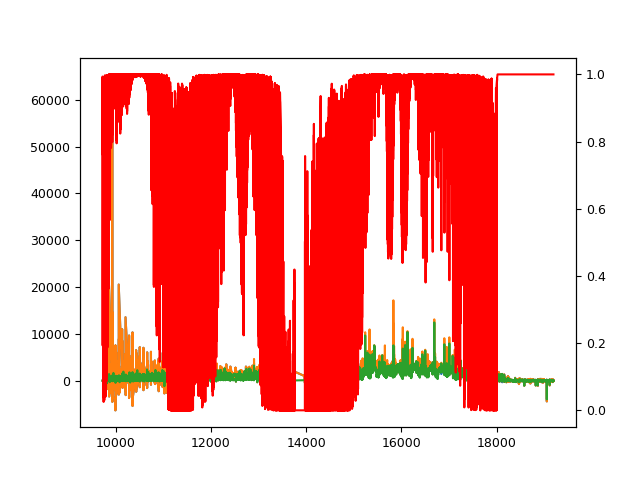

In [78]:
plt.figure()
plt.plot(wave.flatten(),e2ds_skysub.flatten()) # this is what we use in DataSet by default
plt.plot(wave.flatten(),e2ds.flatten())
plt.plot(wave.flatten(),blaze.flatten())
plt.twinx().plot(wave.flatten(),tell.flatten(),color='r')


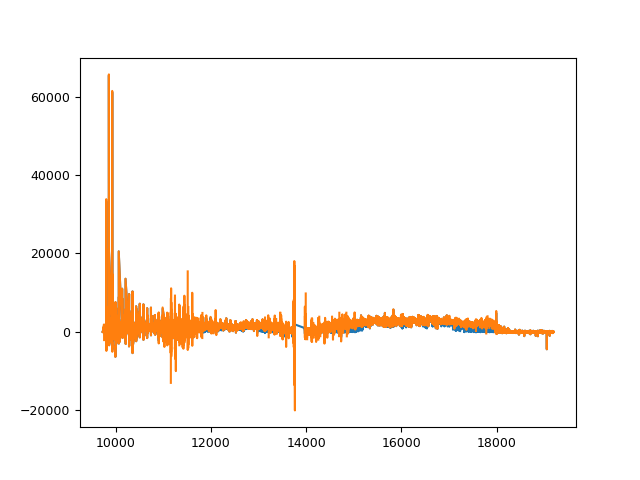

In [90]:
# so for NIRPS we may just have to divide by the telluric template?
plt.figure()
plt.plot(wave.flatten(),e2ds_skysub.flatten())
# mask 0. tellurics
tell_masked = copy.deepcopy(tell)
tell_masked[tell_masked<0.1] = np.nan # we'll clip these values anyway during reduction
plt.plot(wave.flatten(),e2ds_skysub.flatten()/tell_masked.flatten())


In [ ]:
# Conclusion: no need to do molecfit for NIRPS since we already have telluric templates in the data. This may be done automatically following ALlart et al. methodology, to be checked.


### Build s1d files for CARMENES data

In [54]:
# we don't have s1d files ready to go for CARMENES. Either build them or work on e2ds directly?
transit = Kepler91_02072019

dd_vis = DataSet()
dd_vis.load_carmenes_data(transit,channel='vis',callib_on_sky=True)

dd_nir = DataSet()
dd_nir.load_carmenes_data(transit,channel='nir',callib_on_sky=True)

for dd in [dd_vis,dd_nir]:
#     dd.norm_with_scaler()
#     dd.norm_with_median()
    dd.sigma_clipping_on_obs(model_deg=2,max_iter=5,n_sigma=3,plot_sigma=False)


Loading files in '/home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/Kepler-91b/CARMENES/02-07-2019/' :
24 out of 528 files selected !
(61, 4096)

Building data cube of shape : (24, 61, 4096)
Filling the data cube with selected files...
Note that we arbitrary take the SNR from header corresponding to order 30, as SNR has the same relative behavior along time in all orders
Found 24 fiber B telluric correction files in /home/amasson/data/Kaperture_Science/Data/Postdoc_Madrid/Kepler-91b/CARMENES/02-07-2019/
(24, 61, 4096) (24, 61, 4096)
Sky emission from channel B have been saved as attribute self.sky_emission!

Building the off-transit spectra masked :

24 / 24
Found 6 off-transit spectra among 24 spectra

Find off transit spectra done !

This step has been saved with ID : 'find_off_transit'
------------------------------
Compute Kepler orbit done
Compute transit window weight orbit done
Removed empty or null columns from data cube

24 files have been succesfully loaded from '/home

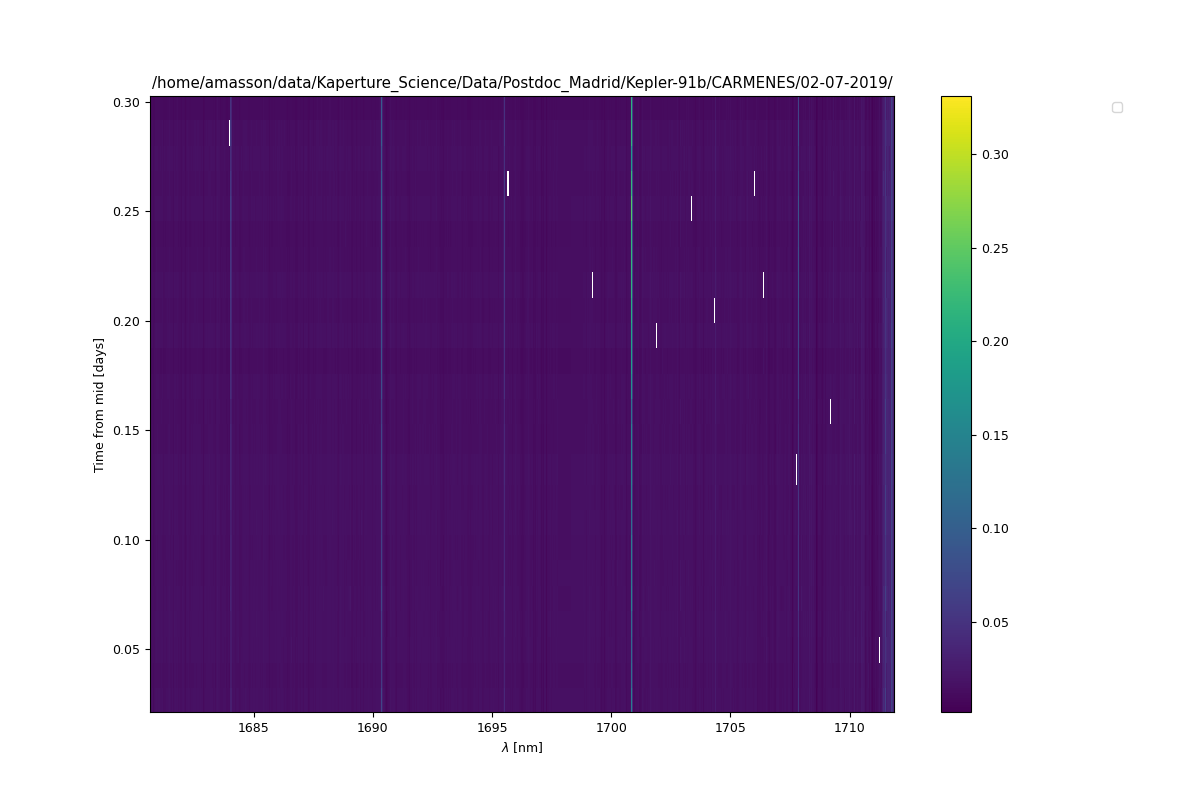

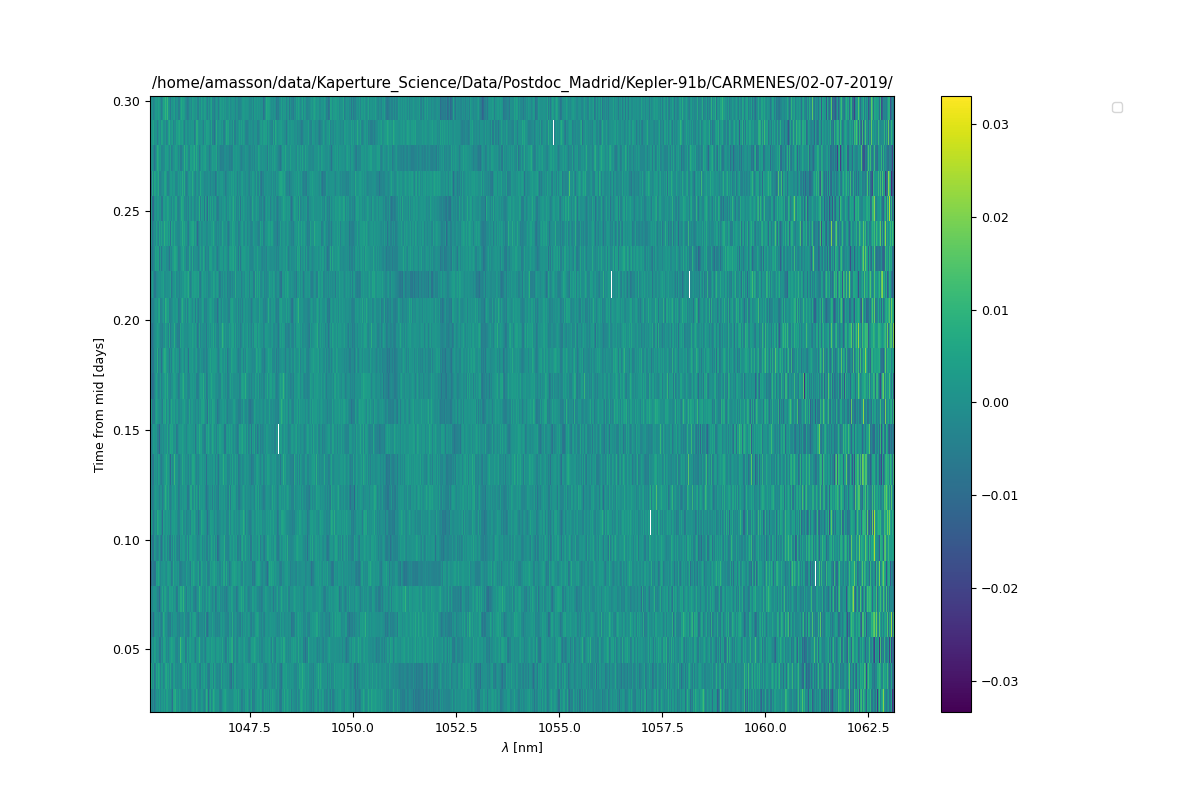

In [55]:
dd_nir.plot_imshow(-1)
dd_vis.plot_imshow(-1)


672/672
Fit & substract sky emission done !

This step has been saved with ID : 'substract_sky'
------------------------------
1464/1464
Fit & substract sky emission done !

This step has been saved with ID : 'substract_sky'
------------------------------


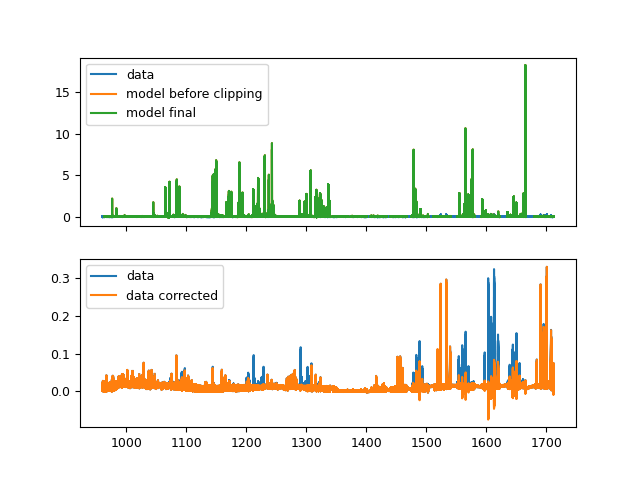

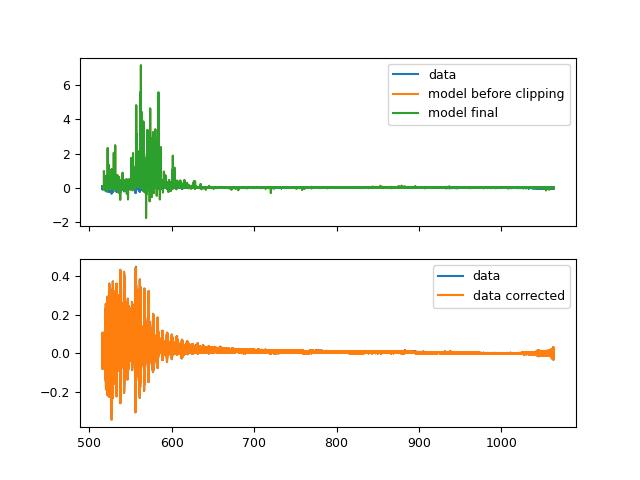

In [56]:
for dd in [dd_nir,dd_vis]:
    dd.substract_sky(plot=True)


./Automated_Program/Kepler-91b_CARMENES_02-07-2019_CARMENES_VIS_S1D.csv ./Automated_Program/Kepler-91b_CARMENES_02-07-2019_CARMENES_NIR_S1D.csv
24 24


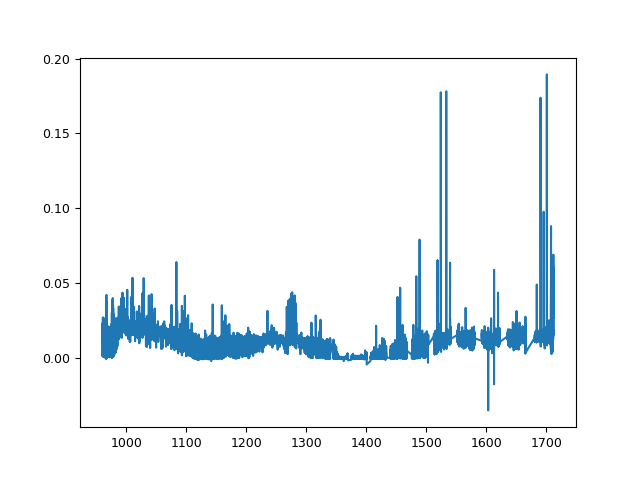

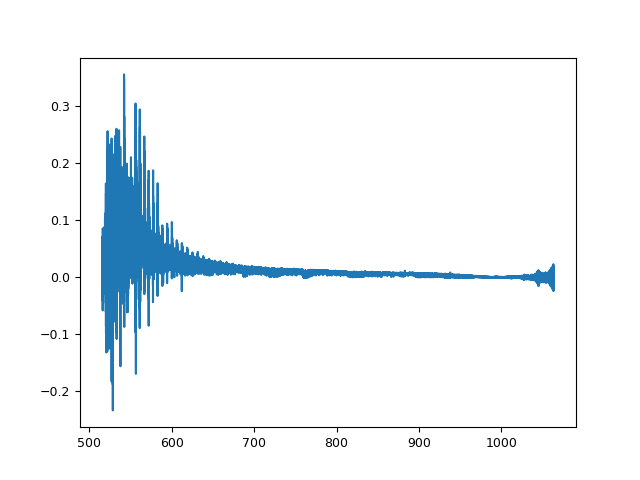

In [72]:
# testing s1d building for CARMENES
def _merge_overlaps_sorted(wave, flux, err, tol):
    if wave.size == 0:
        return wave, flux, err
    # group label: new group wherever step > tol
    labels = np.zeros(wave.size, dtype=np.intp)
    labels[1:] = np.cumsum(np.diff(wave) > tol)
    n_groups = int(labels[-1]) + 1

    good = np.isfinite(wave) & np.isfinite(flux) & np.isfinite(err) & (err > 0)
    wgt = np.where(good, 1.0 / (err * err), 0.0)

    sw   = np.zeros(n_groups)
    sww  = np.zeros(n_groups)
    swf  = np.zeros(n_groups)
    np.add.at(sw,  labels, wgt)
    np.add.at(sww, labels, wgt * wave)
    np.add.at(swf, labels, wgt * flux)

    valid = sw > 0
    return sww[valid] / sw[valid], swf[valid] / sw[valid], np.sqrt(1.0 / sw[valid])

def prepare_s1d(dd, output_dir, csv_path, channel, berv_in_kms=False,
                err_mode="snr", default_snr=100.0, merge_overlaps=True,
                overlap_tol_factor=0.25, min_points=32):
    os.makedirs(output_dir, exist_ok=True)
    rows = []
    for i_obs in range(int(dd.data.shape[0])):
        fname = dd.files[i_obs]
        with fits.open(dd.path + fname) as hdul:
            primary_header = hdul[0].header.copy()
        wave_1d = np.asarray(dd.wave[i_obs], dtype=float).ravel()
        flux_1d = np.asarray(dd.data[i_obs], dtype=float).ravel()
        good = np.isfinite(wave_1d) & np.isfinite(flux_1d)
        wave_1d, flux_1d = wave_1d[good], flux_1d[good]
        s = np.argsort(wave_1d)
        wave_1d, flux_1d = wave_1d[s], flux_1d[s]
        if wave_1d.size < min_points:
            continue
        snr = (float(dd.SNR[i_obs])
               if (hasattr(dd, 'SNR') and dd.SNR is not None
                   and np.isfinite(float(dd.SNR[i_obs]))
                   and float(dd.SNR[i_obs]) > 0)
               else default_snr)
        if err_mode == "snr":
            err_1d = np.full_like(flux_1d, 1.0 / max(snr, 1.0))
        else:
            err_1d = np.ones_like(flux_1d)
        if merge_overlaps:
            d = np.diff(wave_1d)
            d = d[np.isfinite(d) & (d > 0)]
            if d.size > 0:
                tol = overlap_tol_factor * np.nanmedian(d)
                wave_1d, flux_1d, err_1d = _merge_overlaps_sorted(wave_1d, flux_1d, err_1d, tol)
        if wave_1d.size < min_points:
            continue
        table = Table([[wave_1d], [flux_1d], [err_1d]], names=["WAVE", "FLUX", "ERR"])
        obs_key = os.path.splitext(os.path.basename(fname))[0]
        out_path = os.path.join(output_dir, f"{obs_key}_S1D_{str(channel).upper()}.fits")
        fits.HDUList([
            fits.PrimaryHDU(header=primary_header),
            fits.BinTableHDU(table)
        ]).writeto(out_path, overwrite=True, output_verify="silentfix")
        berv = float(dd.BERV[i_obs]) if hasattr(dd, "BERV") else np.nan
        if berv_in_kms and np.isfinite(berv):
            berv *= 1000.0
        rows.append({"path": out_path, "berv": berv})

        if i_obs==0:
            plt.figure()
            plt.plot(wave_1d,flux_1d)

    df = pd.DataFrame(rows, columns=["path", "berv"])
    df.to_csv(csv_path, index=False)

    return df

    # print(f"\nDone. {len(dd.files)} files saved to {output_dir}")

df_nir = prepare_s1d(
    dd_nir,
    output_dir="./s1d_carmenes_nir",
    csv_path=f"./Automated_Program/{dd_nir.name}_CARMENES_NIR_S1D.csv",
    channel="nir",
)

df_vis = prepare_s1d(
    dd_vis,
    output_dir="./s1d_carmenes_vis",
    csv_path=f"./Automated_Program/{dd_vis.name}_CARMENES_VIS_S1D.csv",
    channel="vis",
)

print(f"./Automated_Program/{dd_vis.name}_CARMENES_VIS_S1D.csv",f"./Automated_Program/{dd_vis.name}_CARMENES_NIR_S1D.csv")

print(len(df_nir), len(df_vis))


In [63]:
# # Build per-order CARMENES inputs for the wrapper two-pass mode
# import os
# import numpy as np
# import pandas as pd
# from astropy.io import fits
# from astropy.table import Table

# def save_dataset_as_order1d_carmenes(dd, output_dir, channel='nir', scale_mode='p90'):
#     """
#     Export each (observation, order) as an individual 1D FITS file for orderwise molecfit.

#     Output CSV columns are compatible with the wrapper two-pass order mode:
#     path, berv, obs_key, order_index
#     """
#     os.makedirs(output_dir, exist_ok=True)
#     records = []

#     n_obs, n_ord, _ = dd.data.shape
#     for i_obs, fname in enumerate(dd.files):
#         orig_path = dd.path + fname
#         with fits.open(orig_path) as hdul:
#             primary_header = hdul[0].header.copy()

#         obs_key = os.path.splitext(os.path.basename(fname))[0]
#         berv = float(dd.BERV[i_obs]) if hasattr(dd, 'BERV') else np.nan

#         for i_ord in range(n_ord):
#             wave_ord = np.asarray(dd.wave[i_obs, i_ord], dtype=float)
#             flux_ord = np.asarray(dd.data[i_obs, i_ord], dtype=float)

#             # Keep order-relative line depths: use one robust scalar per order.
#             if scale_mode == 'p90':
#                 scale = np.nanpercentile(flux_ord, 90)
#             elif scale_mode == 'median':
#                 scale = np.nanmedian(flux_ord)
#             else:
#                 scale = 1.0
#             if np.isfinite(scale) and scale != 0:
#                 flux_ord = flux_ord / scale

#             valid = np.isfinite(wave_ord) & np.isfinite(flux_ord)
#             wave_1d = wave_ord[valid]
#             flux_1d = flux_ord[valid]

#             if wave_1d.size < 16:
#                 continue

#             sort_idx = np.argsort(wave_1d)
#             wave_1d = wave_1d[sort_idx]
#             flux_1d = flux_1d[sort_idx]

#             snr = float(dd.SNR[i_obs]) if hasattr(dd, 'SNR') and dd.SNR is not None else 100.0
#             err_1d = np.full_like(flux_1d, 1.0 / max(snr, 1.0))

#             hdr = primary_header.copy()
#             hdr['HIERARCH WRAPPER OBSKEY'] = obs_key
#             hdr['HIERARCH WRAPPER ORDER'] = int(i_ord)
#             hdr['HIERARCH WRAPPER CHAN'] = str(channel).upper()

#             primary_hdu = fits.PrimaryHDU(header=hdr)
#             table = Table([wave_1d, flux_1d, err_1d], names=['WAVE', 'FLUX', 'ERR'])
#             table_hdu = fits.BinTableHDU(table)

#             out_name = f"{obs_key}_ord{i_ord:03d}.fits"
#             out_path = os.path.join(output_dir, out_name)
#             fits.HDUList([primary_hdu, table_hdu]).writeto(
#                 out_path, overwrite=True, output_verify='silentfix'
#             )

#             records.append({
#                 'path': out_path,
#                 'berv': berv,
#                 'obs_key': obs_key,
#                 'order_index': int(i_ord),
#             })

#     return pd.DataFrame.from_records(records)

# # Usage
# order_dir = './order1d_carmenes/'
# df_nir = save_dataset_as_order1d_carmenes(dd_nir, order_dir, channel='nir', scale_mode='p90')
# df_vis = save_dataset_as_order1d_carmenes(dd_vis, order_dir, channel='vis', scale_mode='p90')

# csv_nir = f"./Automated_Program/{dd_nir.name}_CARMENES_NIR_ORDERWISE.csv"
# csv_vis = f"./Automated_Program/{dd_vis.name}_CARMENES_VIS_ORDERWISE.csv"
# df_nir.to_csv(csv_nir, index=False)
# df_vis.to_csv(csv_vis, index=False)

# print(f"NIR orders exported: {len(df_nir)} -> {csv_nir}")
# print(f"VIS orders exported: {len(df_vis)} -> {csv_vis}")


In [64]:
    # file_test = fits.open('./order1d_carmenes/car-20190702T20h55m20s-sci-amap-nir_A_ord001.fits')


In [65]:
# file_test.info()


In [66]:
# table = file_test[1].data
# table.names
# plt.figure()
# plt.plot(table['WAVE'],table['FLUX'])


In [67]:
# plt.figure()
# plt.plot(file_test[])


In [ ]:
# dd_nir.shape
# # 


In [69]:
# dd_vis.shape


### Plot Results: CARMENES (orderwise molecfit)

Found run dirs: 8
 - output16_CARMENES_NIR_20260508_182548
 - output17_CARMENES_NIR_20260508_182548
 - output22_CARMENES_NIR_20260508_182548
 - output24_CARMENES_NIR_20260508_182548
 - output25_CARMENES_NIR_20260508_182548
 - output26_CARMENES_NIR_20260508_182548
 - output8_CARMENES_NIR_20260508_182548
 - output9_CARMENES_NIR_20260508_182548
output16_CARMENES_NIR_20260508_182548: [16]


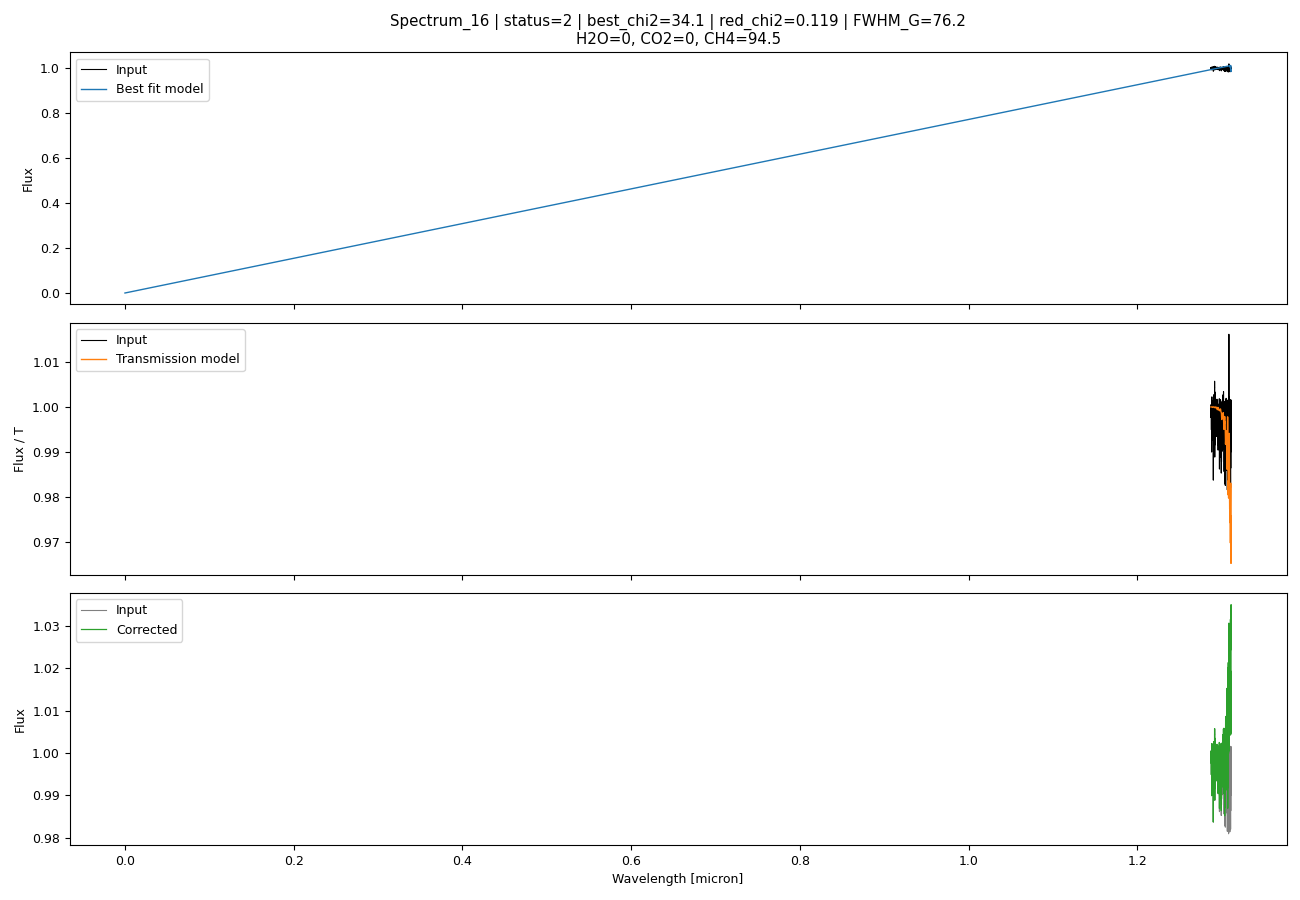

output17_CARMENES_NIR_20260508_182548: [17]


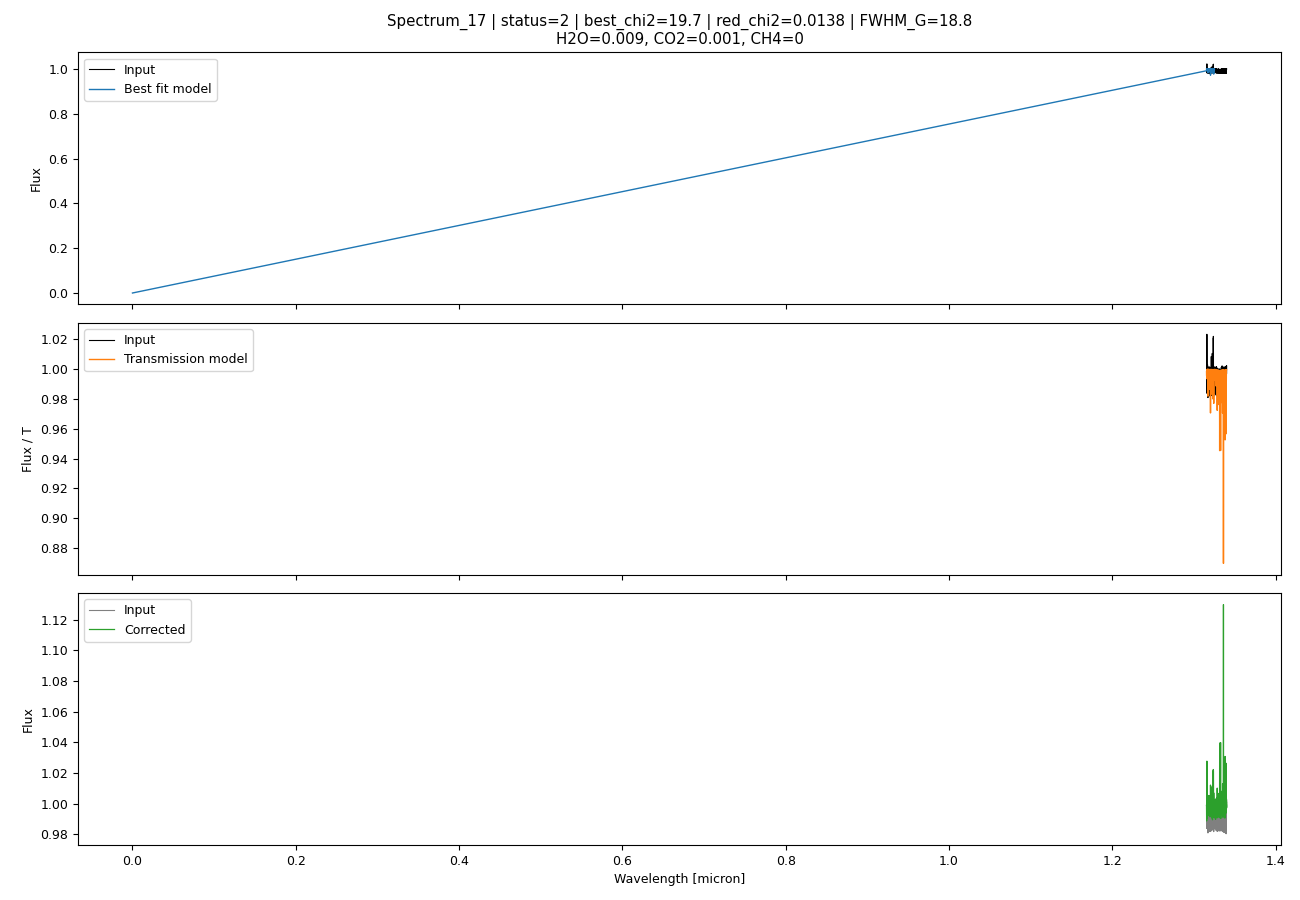

output22_CARMENES_NIR_20260508_182548: [22]


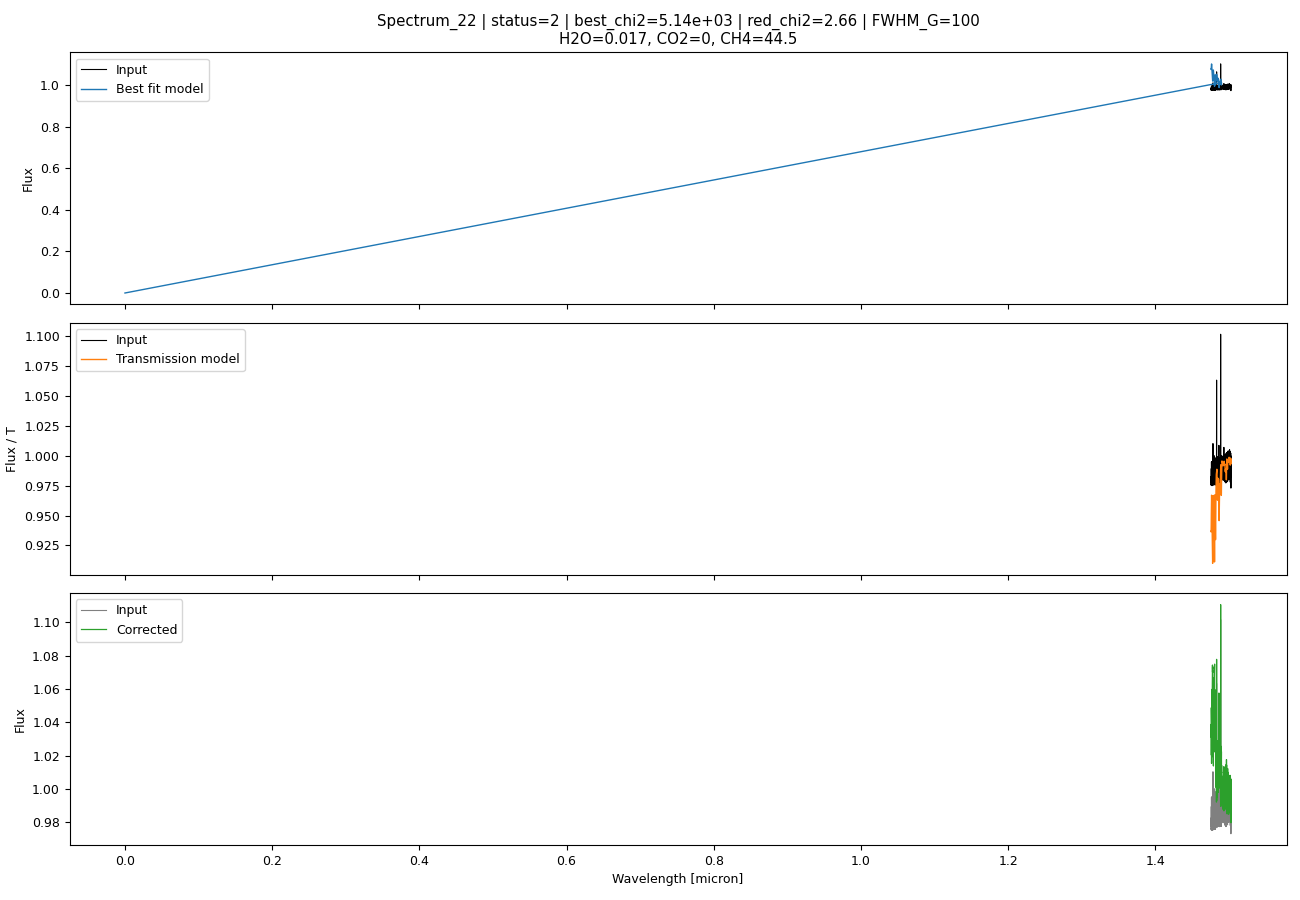

output24_CARMENES_NIR_20260508_182548: [24]


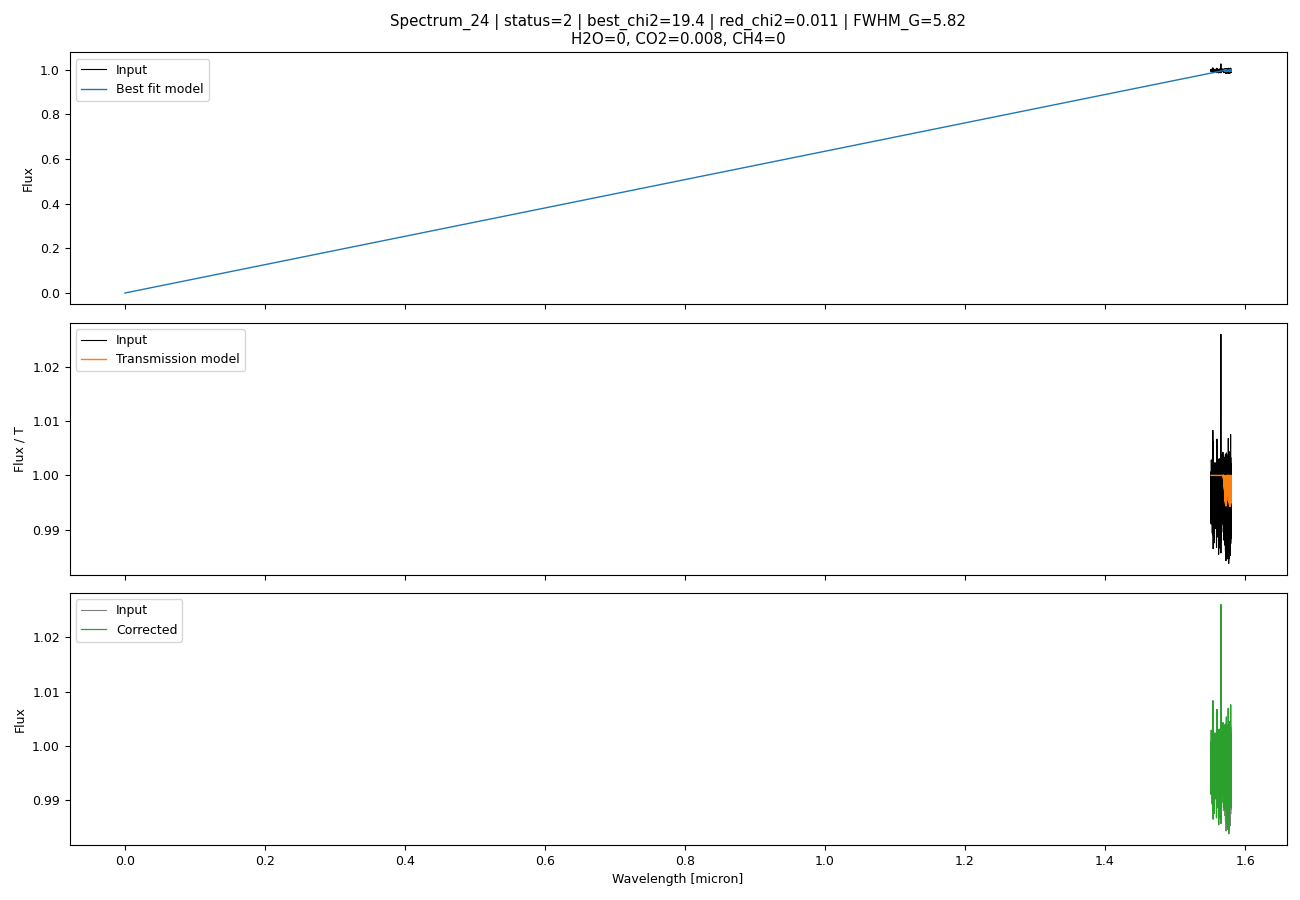

output25_CARMENES_NIR_20260508_182548: [25]


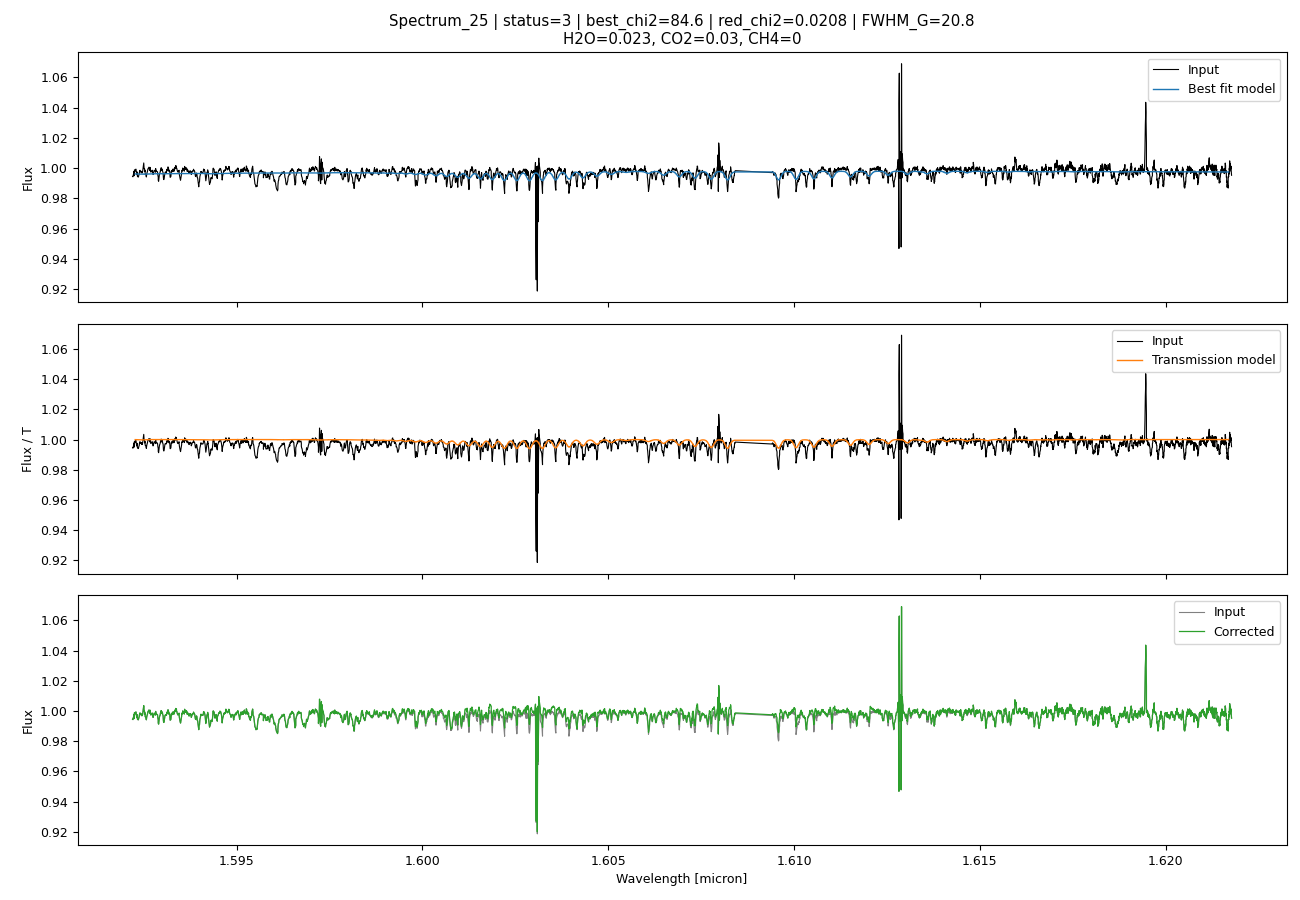

output26_CARMENES_NIR_20260508_182548: [26]


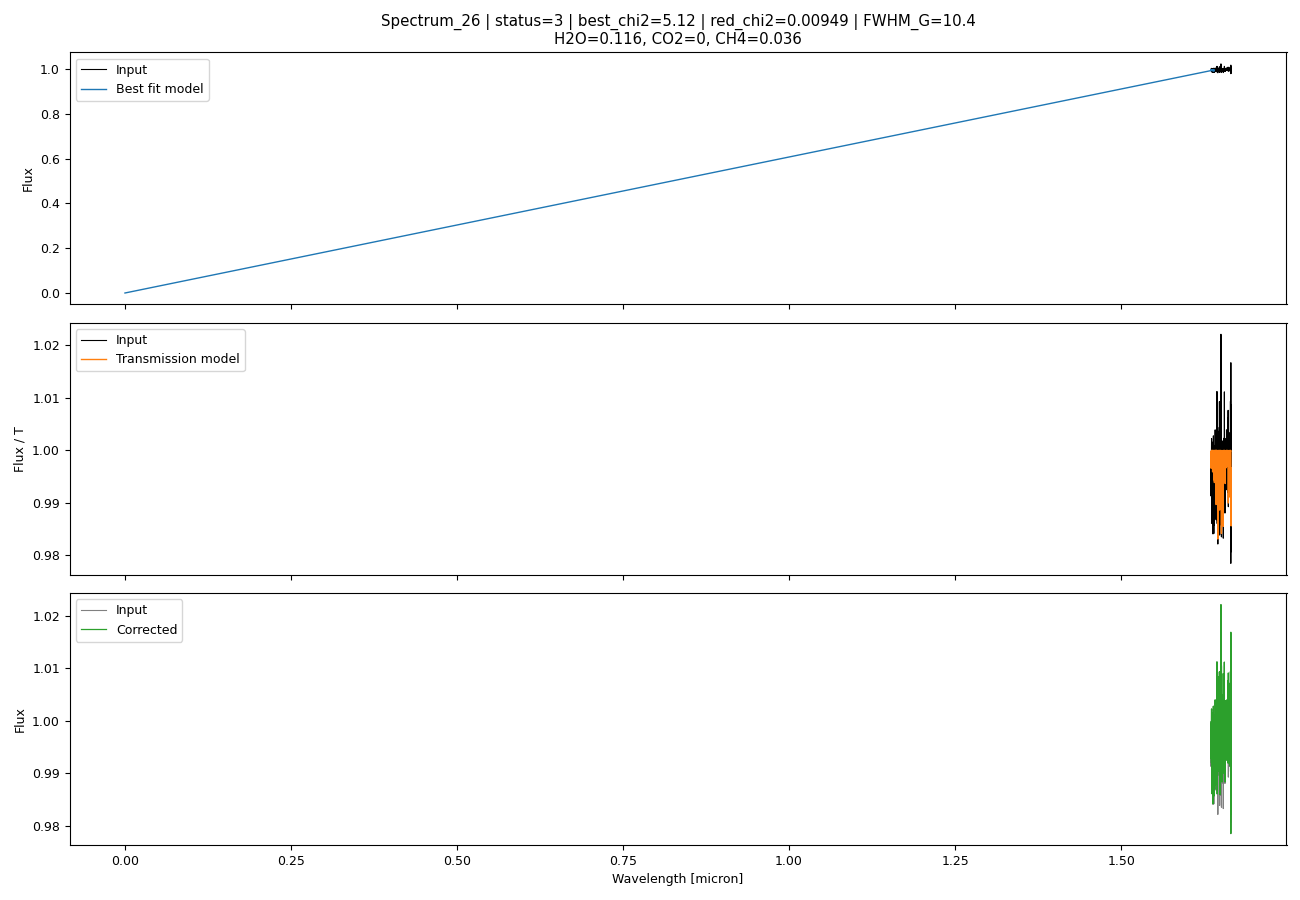

output8_CARMENES_NIR_20260508_182548: [8]


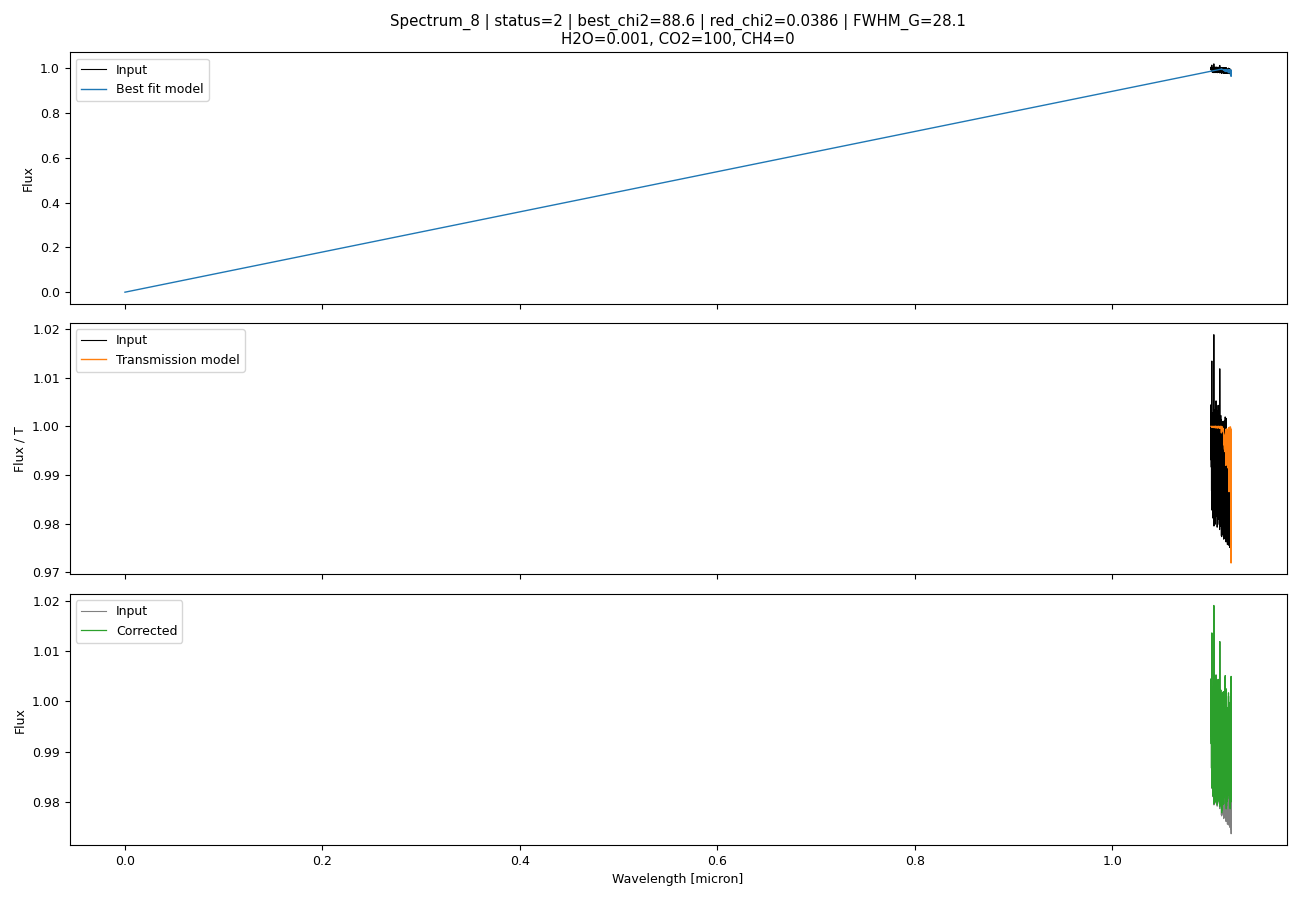

output9_CARMENES_NIR_20260508_182548: [9]


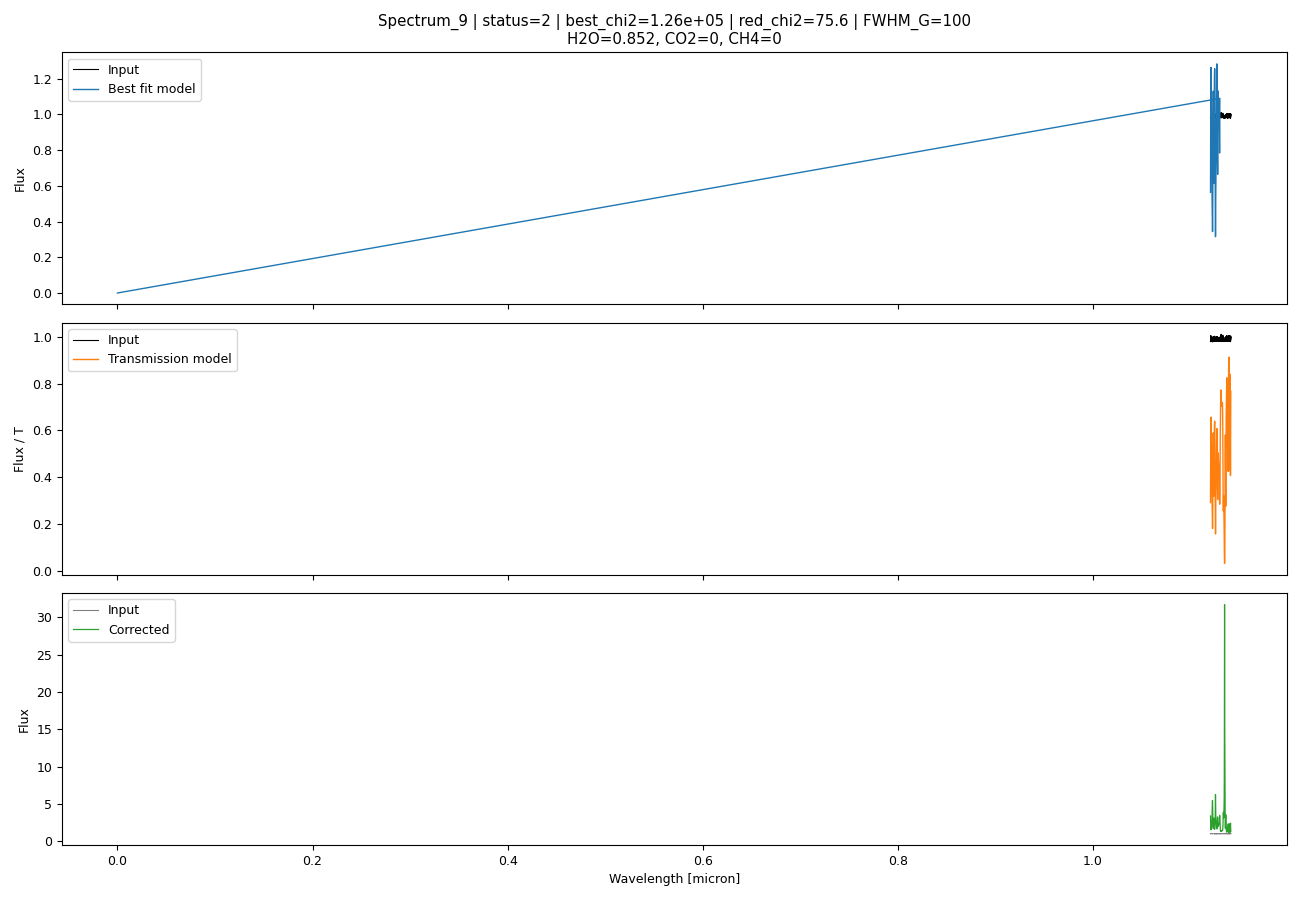

In [34]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Config
# =========================
import os
import glob

# all folders for one run tag
run_dirs = sorted(glob.glob("/home/amasson/data/molecfit_wrapper/Output/output*_CARMENES_NIR_20260508_182548/"))
print("Found run dirs:", len(run_dirs))
for rd in run_dirs:
    print(" -", os.path.basename(os.path.normpath(rd)))
# =========================
# Helpers
# =========================
def _detect_spectrum_indices(run_dir):
    res_files = sorted(glob.glob(os.path.join(run_dir, "Spectrum_*_fit.res")))
    idxs = []
    for p in res_files:
        m = re.search(r"Spectrum_(\d+)_fit\.res$", os.path.basename(p))
        if m:
            idxs.append(int(m.group(1)))
    return idxs

def _read_res_summary(res_path):
    out = {
        "status": np.nan,
        "initial_chi2": np.nan,
        "best_chi2": np.nan,
        "reduced_chi2": np.nan,
        "fwhm_gauss_pix": np.nan,
        "molecules": {},   # name -> (value, err)
    }
    if not os.path.exists(res_path):
        return out

    with open(res_path, "r") as f:
        lines = f.readlines()

    in_mol = False
    for line in lines:
        s = line.strip()

        # Scalars
        m = re.match(r"^Status:\s*([0-9.eE+\-]+)", s)
        if m:
            out["status"] = float(m.group(1))

        m = re.match(r"^Initial chi2:\s*([0-9.eE+\-]+)", s, flags=re.IGNORECASE)
        if m:
            out["initial_chi2"] = float(m.group(1))

        m = re.match(r"^Best chi2:\s*([0-9.eE+\-]+)", s, flags=re.IGNORECASE)
        if m:
            out["best_chi2"] = float(m.group(1))

        m = re.match(r"^Reduced chi2:\s*([0-9.eE+\-]+)", s, flags=re.IGNORECASE)
        if m:
            out["reduced_chi2"] = float(m.group(1))

        m = re.match(r"^FWHM of Gaussian in pixels:\s*([0-9.eE+\-]+)\s*\+\-\s*([0-9.eE+\-]+)", s)
        if m:
            out["fwhm_gauss_pix"] = float(m.group(1))

        # Molecule block start
        if re.match(r"^RELATIVE MOLECULAR GAS COLUMNS:", s, flags=re.IGNORECASE):
            in_mol = True
            continue

        # Molecule block parsing
        if in_mol:
            if s == "":
                continue
            # stop at next section
            if re.match(r"^[A-Z][A-Z\s\-]+:$", s) and not re.match(r"^[A-Za-z0-9_+\-]+:\s*", s):
                break

            # example: H2O: 0.116 +- 0.253
            m = re.match(r"^([A-Za-z0-9_+\-]+):\s*([0-9.eE+\-]+)\s*\+\-\s*([0-9.eE+\-]+)", s)
            if m:
                out["molecules"][m.group(1)] = (float(m.group(2)), float(m.group(3)))

    return out

def _parse_par_value(par_path, key):
    if not os.path.exists(par_path):
        return None
    with open(par_path, "r") as f:
        for line in f:
            s = line.strip()
            if s.startswith(f"{key}:"):
                return s.split(":", 1)[1].strip()
    return None

def _load_ranges(path, run_dir):
    if path is None:
        return []
    if not os.path.isabs(path):
        path = os.path.join(run_dir, path)
    if (not os.path.exists(path)) or os.path.getsize(path) == 0:
        return []
    arr = np.loadtxt(path)
    arr = np.atleast_2d(arr)
    return [(float(r[0]), float(r[1])) for r in arr]

def _read_fit_ascii_fit(path):
    names = ["chip", "lambda", "flux", "weight", "mrange", "mlambda", "mscal", "mflux", "mweight", "dev", "mtrans"]
    arr = np.genfromtxt(
        path,
        comments="!",
        names=names,
        usecols=tuple(range(1, 12)),
        skip_header=1,
    )
    return (
        np.asarray(arr["lambda"], dtype=float),
        np.asarray(arr["flux"], dtype=float),
        np.asarray(arr["mlambda"], dtype=float),
        np.asarray(arr["mflux"], dtype=float),
    )

def _read_fit_ascii_tac(path):
    names = ["chip", "lambda", "flux", "weight", "mlambda", "mtrans", "mweight", "cflux", "qual"]
    arr = np.genfromtxt(
        path,
        comments="!",
        names=names,
        usecols=tuple(range(1, 10)),
        skip_header=1,
    )
    return (
        np.asarray(arr["lambda"], dtype=float),
        np.asarray(arr["flux"], dtype=float),
        np.asarray(arr["mlambda"], dtype=float),
        np.asarray(arr["mtrans"], dtype=float),
        np.asarray(arr["cflux"], dtype=float),
    )

# =========================
# Main
# =========================
# indices = _detect_spectrum_indices(run_dir)
# if len(indices) == 0:
#     raise RuntimeError(f"No Spectrum_*_fit.res found in {run_dir}")

# =========================
# Select what to plot
# =========================
# indices_all = _detect_spectrum_indices(run_dir)
# if len(indices_all) == 0:
#     raise RuntimeError(f"No Spectrum_*_fit.res found in {run_dir}")

# plot_mode = "all"          # "all", "one", "list", "slice"
# one_index = 26             # used if plot_mode == "one"
# index_list = [20, 21, 26]  # used if plot_mode == "list"
# slice_start = 20           # used if plot_mode == "slice"
# slice_stop = 30            # used if plot_mode == "slice" (excluded)

# if plot_mode == "all":
#     indices = indices_all
# elif plot_mode == "one":
#     indices = [one_index] if one_index in indices_all else []
# elif plot_mode == "list":
#     indices = [i for i in index_list if i in indices_all]
# elif plot_mode == "slice":
#     indices = [i for i in indices_all if slice_start <= i < slice_stop]
# else:
#     raise ValueError(f"Unknown plot_mode: {plot_mode}")

# print(f"Found {len(indices_all)} spectra, plotting {len(indices)}: {indices[:12]}{'...' if len(indices)>12 else ''}")

for run_dir in run_dirs:
    indices = _detect_spectrum_indices(run_dir)
    if len(indices) == 0:
        continue

    print(f"{os.path.basename(os.path.normpath(run_dir))}: {indices}")

    for idx in indices:
        # your existing block unchanged
        res_path = os.path.join(run_dir, f"Spectrum_{idx}_fit.res")
        par_path = os.path.join(run_dir, f"Spectrum_{idx}_fit.par")
        fit_path = os.path.join(run_dir, f"Spectrum_{idx}_fit.asc")
        tac_path = os.path.join(run_dir, f"Spectrum_{idx}_tac.asc")
# for idx in indices:
#     res_path = os.path.join(run_dir, f"Spectrum_{idx}_fit.res")
#     par_path = os.path.join(run_dir, f"Spectrum_{idx}_fit.par")
#     fit_path = os.path.join(run_dir, f"Spectrum_{idx}_fit.asc")
#     tac_path = os.path.join(run_dir, f"Spectrum_{idx}_tac.asc")

        if (not os.path.exists(fit_path)) or (not os.path.exists(tac_path)):
            print(f"Skip Spectrum_{idx}: missing fit/tac ascii")
            continue

        info = _read_res_summary(res_path)

        # include/exclude paths: prefer par values, fallback to include_idx.dat / exclude_idx.dat
        inc_raw = _parse_par_value(par_path, "wrange_include")
        exc_raw = _parse_par_value(par_path, "wrange_exclude")
        if inc_raw is None:
            inc_raw = f"include_{idx}.dat"
        if exc_raw is None:
            exc_raw = f"exclude_{idx}.dat"
        inc_ranges = _load_ranges(inc_raw, run_dir)
        exc_ranges = _load_ranges(exc_raw, run_dir)

        w_fit, f_fit, w_model_fit, model_fit = _read_fit_ascii_fit(fit_path)
        w_tac, f_tac, w_model_tac, model_tac, cflux_tac = _read_fit_ascii_tac(tac_path)

        mol_txt = ", ".join([f"{k}={v[0]:.3g}" for k, v in info["molecules"].items()])
        title = (
            f"Spectrum_{idx} | status={info['status']:.0f} | "
            f"best_chi2={info['best_chi2']:.3g} | red_chi2={info['reduced_chi2']:.3g} | "
            f"FWHM_G={info['fwhm_gauss_pix']:.3g}"
        )
        if len(mol_txt) > 0:
            title += "\n" + mol_txt

        fig, ax = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

        # Panel 1: fit
        ax[0].plot(w_fit, f_fit, color="k", lw=0.8, label="Input")
        ax[0].plot(w_model_fit, model_fit, color="tab:blue", lw=1.0, label="Best fit model")
        ax[0].set_ylabel("Flux")
        ax[0].legend(loc="best")
        ax[0].set_title(title)

        # Panel 2: transmission + include/exclude
        ax[1].plot(w_tac, f_tac, color="k", lw=0.8, label="Input")
        ax[1].plot(w_model_tac, model_tac, color="tab:orange", lw=1.0, label="Transmission model")
        for i, (lo, hi) in enumerate(inc_ranges):
            ax[1].axvspan(lo, hi, color="green", alpha=0.16, label="Included" if i == 0 else None)
        for i, (lo, hi) in enumerate(exc_ranges):
            ax[1].axvspan(lo, hi, color="red", alpha=0.16, label="Excluded" if i == 0 else None)
        ax[1].set_ylabel("Flux / T")
        ax[1].legend(loc="best")

        # Panel 3: corrected
        ax[2].plot(w_tac, f_tac, color="0.5", lw=0.8, label="Input")
        ax[2].plot(w_tac, cflux_tac, color="tab:green", lw=0.9, label="Corrected")
        ax[2].set_xlabel("Wavelength [micron]")
        ax[2].set_ylabel("Flux")
        ax[2].legend(loc="best")

        plt.tight_layout()
        plt.show()


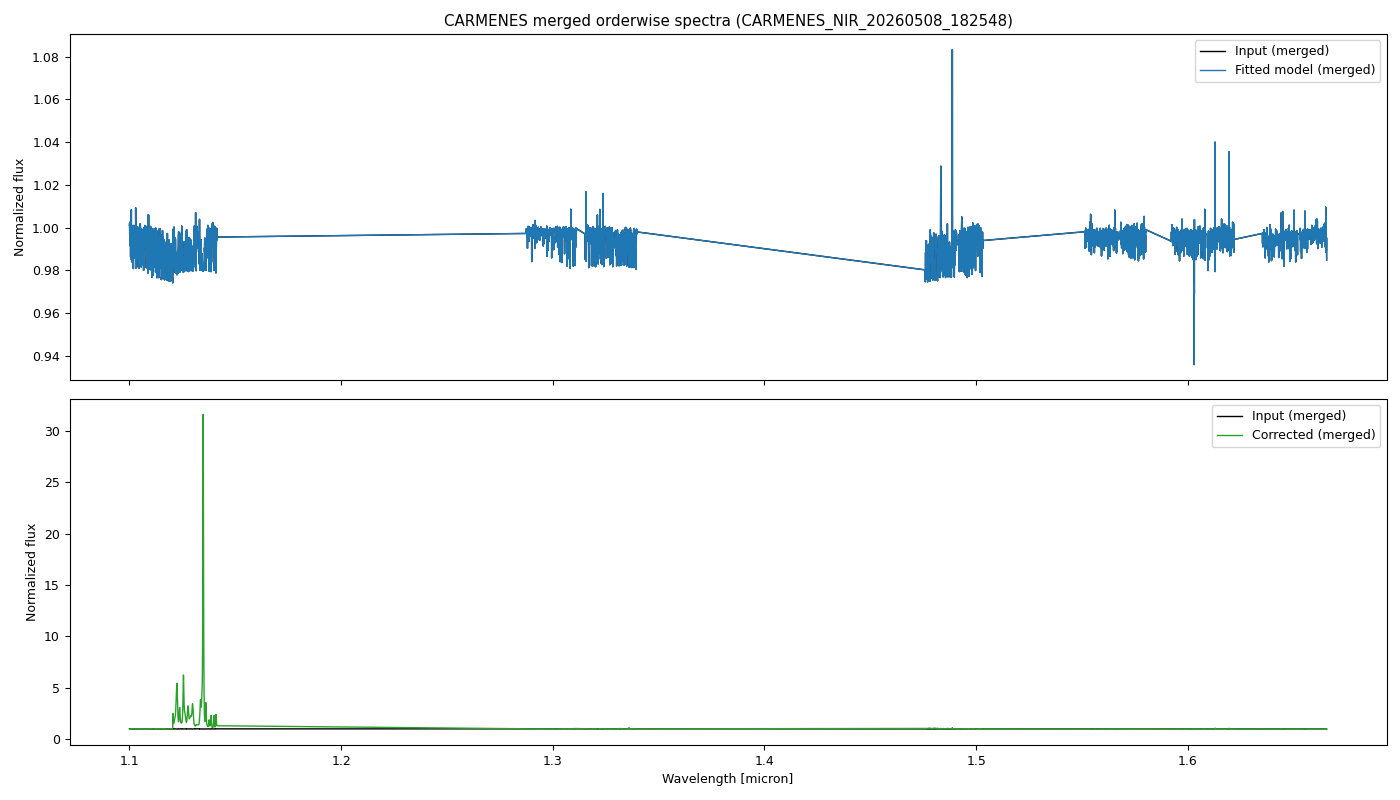

Orders merged: 8
Wavelength span: 1.100050 - 1.665590 micron
Grid step: 2.00e-05 micron (0.2 A)


In [35]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Config
# =========================
output_root = "/home/amasson/data/molecfit_wrapper/Output"
run_tag = "CARMENES_NIR_20260508_182548"
bin_size_A = 0.2
edge_trim_frac = 0.07
apply_taper = True
show_each_order = False

# =========================
# Helpers
# =========================
def read_tac_ascii(path):
    # Spectrum_*_tac.asc columns (skip first unlabeled index column)
    names = ["chip", "lam", "flux", "weight", "mlam", "mtrans", "mweight", "cflux", "qual"]
    arr = np.genfromtxt(
        path, comments="!", names=names, usecols=tuple(range(1, 10)), skip_header=1
    )
    lam = np.asarray(arr["lam"], dtype=float)       # micron
    flux = np.asarray(arr["flux"], dtype=float)     # input
    mtrans = np.asarray(arr["mtrans"], dtype=float) # transmission model
    cflux = np.asarray(arr["cflux"], dtype=float)   # corrected
    qual = np.asarray(arr["qual"], dtype=float)
    return lam, flux, mtrans, cflux, qual

def read_status_and_order(res_path):
    status = np.nan
    order = -1
    if not os.path.exists(res_path):
        return status, order

    with open(res_path, "r") as f:
        txt = f.read()

    m = re.search(r"^\s*Status:\s*([0-9.eE+\-]+)", txt, flags=re.MULTILINE)
    if m:
        status = float(m.group(1))

    # from DATA FILE line: ..._ord026.dat
    mo = re.search(r"_ord(\d+)\.dat", txt)
    if mo:
        order = int(mo.group(1))

    return status, order

def edge_weight(n, trim_frac=0.07, taper=True):
    if n < 10:
        return np.ones(n)
    i = np.arange(n)
    x = (i + 0.5) / n
    core = (x >= trim_frac) & (x <= 1 - trim_frac)
    if not taper:
        return core.astype(float)

    w = np.zeros(n, dtype=float)
    left = x < trim_frac
    mid = core
    right = x > 1 - trim_frac

    w[mid] = 1.0
    if np.any(left):
        xl = x[left] / trim_frac
        w[left] = 0.5 * (1 - np.cos(np.pi * xl))
    if np.any(right):
        xr = (1 - x[right]) / trim_frac
        w[right] = 0.5 * (1 - np.cos(np.pi * xr))
    return w

def weighted_bin(x, y, w, dx):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    w = np.asarray(w, float)

    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)
    x, y, w = x[m], y[m], w[m]
    if x.size == 0:
        return np.array([]), np.array([]), np.array([])

    if not np.isfinite(dx) or dx <= 0:
        raise ValueError(f"dx must be > 0, got {dx}")

    xmin, xmax = np.nanmin(x), np.nanmax(x)
    edges = np.arange(xmin, xmax + 1.5 * dx, dx)
    if edges.size < 2:
        return x, y, w

    nb = edges.size - 1
    idx = np.searchsorted(edges, x, side="right") - 1
    idx = np.clip(idx, 0, nb - 1)

    wy = np.zeros(nb, dtype=float)
    ww = np.zeros(nb, dtype=float)
    wx = np.zeros(nb, dtype=float)

    np.add.at(wy, idx, w * y)
    np.add.at(ww, idx, w)
    np.add.at(wx, idx, w * x)

    good = ww > 0
    xb = wx[good] / ww[good]
    yb = wy[good] / ww[good]
    wb = ww[good]
    return xb, yb, wb

# =========================
# Gather orders
# =========================
folders = sorted(glob.glob(os.path.join(output_root, f"output*_{run_tag}")))
if len(folders) == 0:
    raise RuntimeError(f"No folders found for run_tag={run_tag}")

orders = []
for folder in folders:
    tac_list = glob.glob(os.path.join(folder, "Spectrum_*_tac.asc"))
    res_list = glob.glob(os.path.join(folder, "Spectrum_*_fit.res"))
    if len(tac_list) == 0 or len(res_list) == 0:
        continue

    tac = tac_list[0]
    res = res_list[0]
    status, order = read_status_and_order(res)

    if np.isfinite(status) and int(status) not in [1, 2, 3]:
        continue

    lam, flux, mtrans, cflux, qual = read_tac_ascii(tac)
    good = np.isfinite(lam) & np.isfinite(flux) & np.isfinite(mtrans) & np.isfinite(cflux) & (qual > 0)
    if np.sum(good) < 20:
        continue

    lam = lam[good]
    flux = flux[good]
    mtrans = mtrans[good]
    cflux = cflux[good]

    s = np.argsort(lam)
    lam, flux, mtrans, cflux = lam[s], flux[s], mtrans[s], cflux[s]

    # Build fitted model in flux space from TAC columns
    fit_flux = cflux * mtrans

    # Normalize each order with ONE scalar from input to preserve relative shape within order
    scale = np.nanpercentile(flux, 95)
    if not np.isfinite(scale) or scale == 0:
        scale = np.nanmedian(flux)
    if not np.isfinite(scale) or scale == 0:
        scale = 1.0

    flux_n = flux / scale
    fit_n = fit_flux / scale
    corr_n = cflux / scale

    w_edge = edge_weight(len(lam), trim_frac=edge_trim_frac, taper=apply_taper)

    orders.append({
        "order": order,
        "lam": lam,
        "flux_n": flux_n,
        "fit_n": fit_n,
        "corr_n": corr_n,
        "w": w_edge,
    })

if len(orders) == 0:
    raise RuntimeError("No valid converged orders found.")

# =========================
# Merge
# =========================
dx_micron = bin_size_A * 1e-4

x_all   = np.concatenate([o["lam"] for o in orders])
in_all  = np.concatenate([o["flux_n"] for o in orders])
fit_all = np.concatenate([o["fit_n"] for o in orders])
cor_all = np.concatenate([o["corr_n"] for o in orders])
w_all   = np.concatenate([o["w"] for o in orders])

xb_in,  yb_in,  _ = weighted_bin(x_all, in_all,  w_all, dx_micron)
xb_fit, yb_fit, _ = weighted_bin(x_all, fit_all, w_all, dx_micron)
xb_cor, yb_cor, _ = weighted_bin(x_all, cor_all, w_all, dx_micron)

# =========================
# Plot: 2 subfigures
# =========================
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

if show_each_order:
    for o in sorted(orders, key=lambda z: z["order"]):
        ax[0].plot(o["lam"], o["flux_n"], lw=0.4, alpha=0.18, color="0.4")
        ax[0].plot(o["lam"], o["fit_n"], lw=0.4, alpha=0.18, color="tab:blue")
        ax[1].plot(o["lam"], o["flux_n"], lw=0.4, alpha=0.14, color="0.4")
        ax[1].plot(o["lam"], o["corr_n"], lw=0.4, alpha=0.18, color="tab:green")

# 1) input + fitted model
ax[0].plot(xb_in,  yb_in,  color="k",        lw=1.0, label="Input (merged)")
ax[0].plot(xb_fit, yb_fit, color="tab:blue", lw=1.0, label="Fitted model (merged)")
ax[0].set_ylabel("Normalized flux")
ax[0].set_title(f"CARMENES merged orderwise spectra ({run_tag})")
ax[0].legend(loc="best")

# 2) input + corrected
ax[1].plot(xb_in,  yb_in,  color="k",         lw=1.0, label="Input (merged)")
ax[1].plot(xb_cor, yb_cor, color="tab:green", lw=1.0, label="Corrected (merged)")
ax[1].set_ylabel("Normalized flux")
ax[1].set_xlabel("Wavelength [micron]")
ax[1].legend(loc="best")

plt.tight_layout()
plt.show()

print(f"Orders merged: {len(orders)}")
print(f"Wavelength span: {np.nanmin(x_all):.6f} - {np.nanmax(x_all):.6f} micron")
print(f"Grid step: {dx_micron:.2e} micron ({bin_size_A} A)")


### Plot results: HARPS/NIRPS/CARMENES (flattened s1d if all orders)

1) load a transit and associated dataset and generate the CSV with s1d file list for molecfit to process
2) setup the Molecfit_run_parallelized.py parameters (first lines, path to s1d files)
3) run in terminal: $ python Molecfit_run_parallelized.py
4) run cells below to check result

/home/amasson/data/molecfit_wrapper/Output/output0_CARMENES_NIR_20260511_111821/include_0.dat


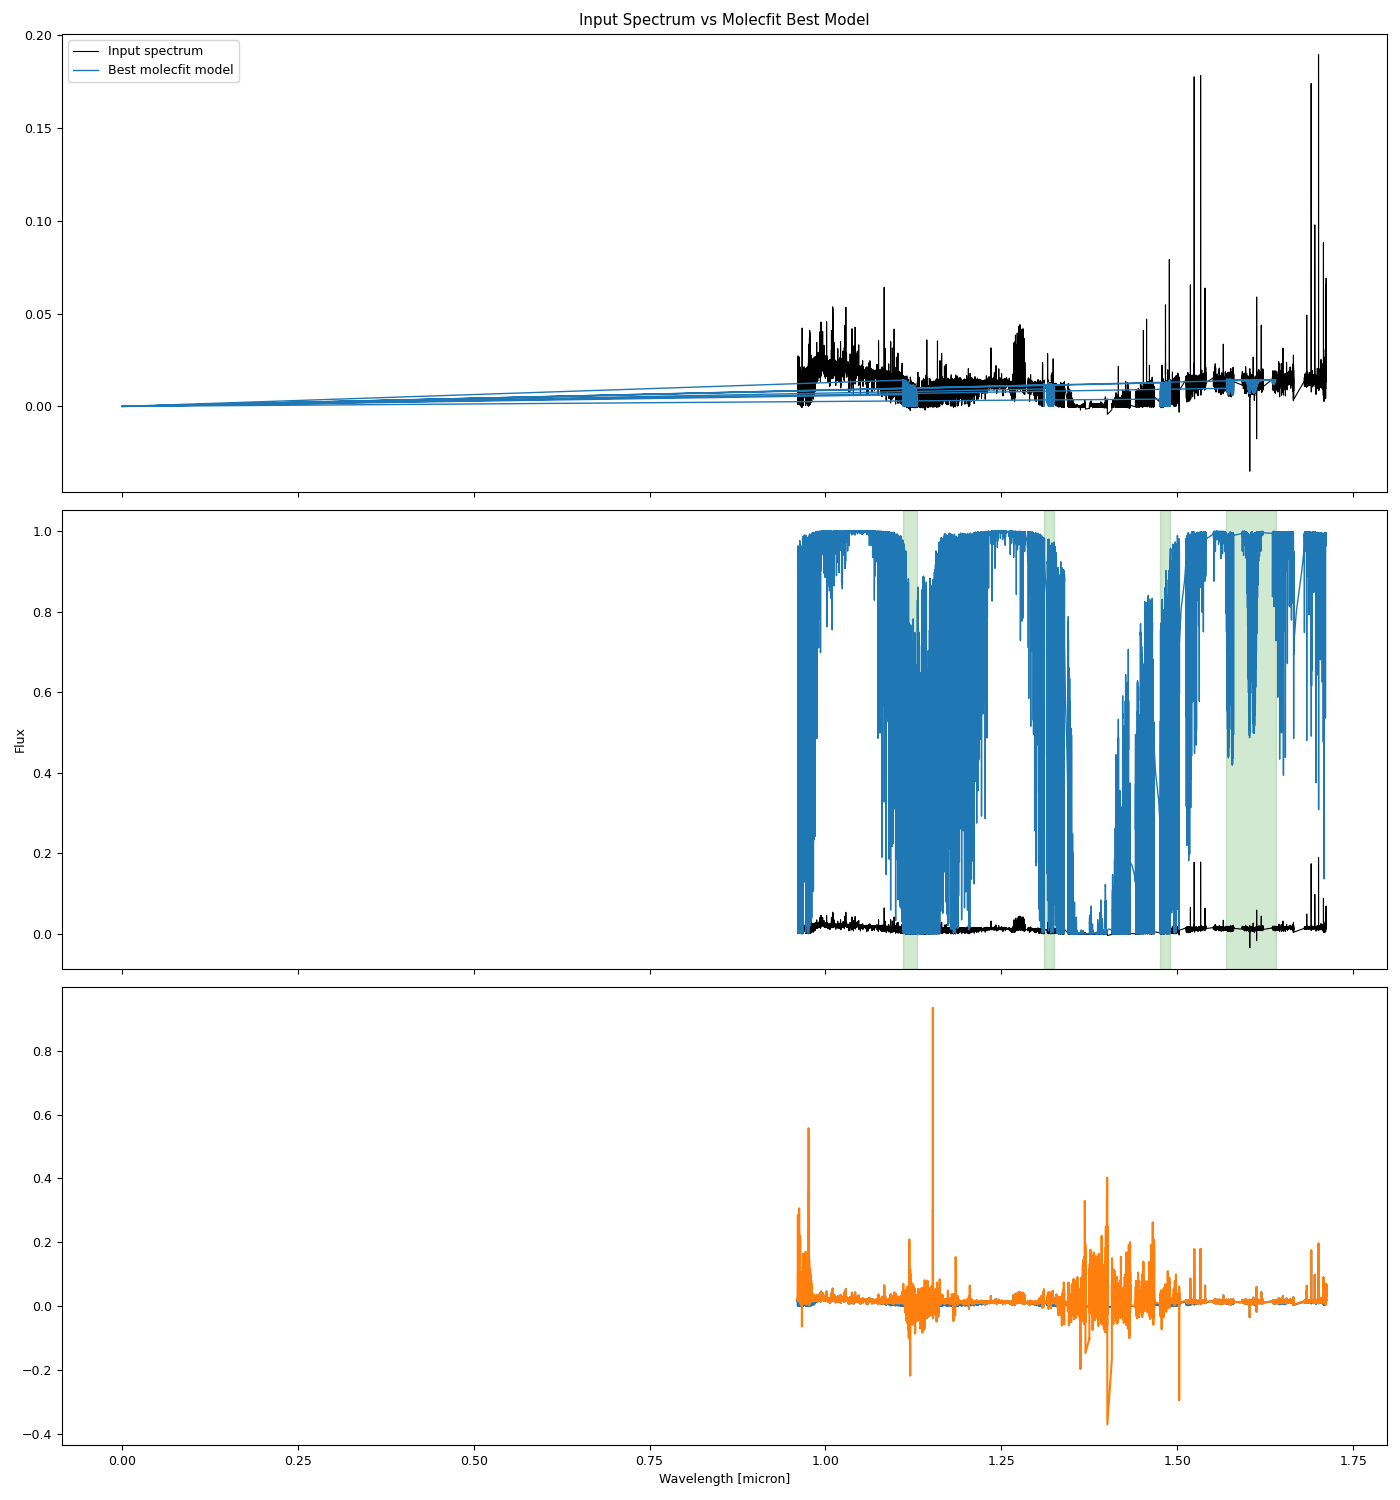

In [70]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

# --- config ---
run_dir = "/home/amasson/data/molecfit_wrapper/Output/output0_CARMENES_NIR_20260511_111821/"
spectrum_index = 0

def _load_ranges(path):
    if path is None or not os.path.exists(path):
        return []
    if os.path.getsize(path) == 0:
        return []
    arr = np.loadtxt(path)
    arr = np.atleast_2d(arr)
    return [(row[0], row[1]) for row in arr]

def _resolve_range_path(par_dir, raw_path, fallback_path):
    # print(raw_path)
    if (raw_path is None) or (raw_path.strip().lower() == "none") or (raw_path.strip() == ""):
        return fallback_path
    if os.path.isabs(raw_path):
        return raw_path
    return os.path.join(par_dir, raw_path)

def _ranges_from_par(run_dir, idx):
    par = os.path.join(run_dir, f"Spectrum_{idx}_fit.par")
    inc_path, exc_path = None, None

    if os.path.exists(par):
        with open(par, "r") as f:
            for line in f:
                if line.strip().startswith("wrange_include:"):
                    inc_path = line.split(":", 1)[1].strip()
                elif line.strip().startswith("wrange_exclude:"):
                    exc_path = line.split(":", 1)[1].strip()

    par_dir = os.path.dirname(par)
    # inc_path = _resolve_range_path(par_dir, inc_path, os.path.join(run_dir, f"include_{idx}.dat"))
    inc_path = run_dir+'include_0.dat'
    # exc_path = _resolve_range_path(par_dir, exc_path, os.path.join(run_dir, f"exclude_{idx}.dat"))
    exc_path = run_dir+'exclude_0.dat'

    print(inc_path)

    inc_ranges = _load_ranges(inc_path)
    exc_ranges = _load_ranges(exc_path)
    return inc_ranges, exc_ranges

def _read_fit_ascii_TAC(run_dir, idx):
    p = os.path.join(run_dir, f"Spectrum_{idx}_tac.asc")
    if not os.path.exists(p):
        raise FileNotFoundError(p)

    # molecfit ASCII has an unlabeled first column -> skip col 0
    names = ["chip","lambda","  flux","  weight","mlambda"," mtrans","mweight"," cflux","qual"]
    arr = np.genfromtxt(
        p,
        comments="!",
        names=names,
        usecols=tuple(range(1, 10)),
        skip_header=1,   
    )
    wave = np.asarray(arr["lambda"], dtype=float)
    flux = np.asarray(arr["flux"], dtype=float)
    model_wave = np.asarray(arr["mlambda"], dtype=float)
    model_flux = np.asarray(arr["mtrans"], dtype=float)
    corrected_flux = np.asarray(arr["cflux"], dtype=float)
    return wave, flux, model_wave, model_flux, corrected_flux

def _read_fit_ascii_fit(run_dir, idx):
    p = os.path.join(run_dir, f"Spectrum_{idx}_fit.asc")
    if not os.path.exists(p):
        raise FileNotFoundError(p)

    # molecfit ASCII has an unlabeled first column -> skip col 0
    names = ["chip","lambda","flux","weight","mrange","mlambda","mscal","mflux","mweight","dev","mtrans"]
    arr = np.genfromtxt(
        p,
        comments="!",
        names=names,
        usecols=tuple(range(1, 12)),
        skip_header=1,   
    )
    wave = np.asarray(arr["lambda"], dtype=float)
    flux = np.asarray(arr["flux"], dtype=float)
    model_wave = np.asarray(arr["mlambda"], dtype=float)
    model_flux = np.asarray(arr["mflux"], dtype=float)
    return wave, flux, model_wave, model_flux

# --- load ---
# transmission model
wave, flux, w_model, model, corrected_flux = _read_fit_ascii_TAC(run_dir, spectrum_index)
# molecfit fit
_, __, w_fit, model_fit = _read_fit_ascii_fit(run_dir, spectrum_index)

inc_ranges, exc_ranges = _ranges_from_par(run_dir, spectrum_index)

# --- plot ---
fig, ax = plt.subplots(3, 1, figsize=(14, 15),sharex=True)

ax[0].plot(wave, flux, color="k", lw=0.8, label="Input spectrum")
ax[0].plot(w_fit, model_fit, color="tab:blue", lw=1.0, label="Best molecfit model")

ax[1].plot(wave, flux, color="k", lw=0.8, label="Input spectrum")
ax[1].plot(w_model, model, color="tab:blue", lw=1.0, label="Best molecfit model")

for i, (lo, hi) in enumerate(inc_ranges):
    ax[1].axvspan(lo, hi, color="green", alpha=0.18, label="Included" if i == 0 else None)

for i, (lo, hi) in enumerate(exc_ranges):
    ax[1].axvspan(lo, hi, color="red", alpha=0.18, label="Excluded" if i == 0 else None)

ax[1].set_ylabel("Flux")
ax[0].set_title("Input Spectrum vs Molecfit Best Model")
ax[0].legend(loc="best")

# replace 0 values in model with 1
# model[model==0] = 1.
ax[2].plot(wave,flux)
ax[2].plot(wave,corrected_flux)
ax[2].set_xlabel("Wavelength [micron]")

plt.tight_layout()
plt.show()
